#Portada

In [ ]:
#Logo UNED
from IPython.core.display import HTML
from IPython.display import Image
display(HTML('<img src="https://n9.cl/clfwp"width="100" align="right">'))



<p align="center"><p align="center"> UNIVERSIDAD ESTATAL A DISTANCIA
 <img src="https://n9.cl/clfwp" width="100" align="right">
<p align="center"> VICERRECTORÍA ACADÉMICA
<p align="center"> ESCUELA DE CIENCIAS EXACTAS Y NATURALES
<p align="center">SISTEMAS DE INFORMACIÓN EN SALUD
<p align="center"> CÁTEDRA GESTIÓN DE LA INFORMACIÓN EN SALUD


<p align="center"> PROYECTO 1: EXPLORACIÓN Y ANÁLISIS DE DATOS ESTADÍSTICOS DE PACIENTES QUE PRESENTAN LA ENFERMEDAD ICTUS


Asignatura:
<p align="center">03579 - Progamación Estadística En Salud II

Estudiante:
<p align="center">Alina Elizondo Sánchez

Número de cédula de identidad:
<p align="center">0604630347

Centro Universitario:
<p align="center">Puntarenas (09)

Tutor:
<p align="center">Marvin Suárez Benson

Fecha entrega:
<p align="center">15/03/2026






# Desarrollo

## Carga de CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Conectar con drive
from google.colab import drive
drive.mount('/content/drive')

#Cargar el cvs
df= pd.read_csv('/content/drive/My Drive/Colab Notebooks/healthcare-dataset-stroke-data.csv')
df.tail()

#Limpieza ligera de nombres
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

print("Columnas:", df.columns.tolist())
print(df.head())

#Detectar variable objetivo más común
possible_targets =['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("Variable objetivo detectada:", target_col)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columnas: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     

In [ ]:
# Variables numéricas
columnas_numericas = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


## Ejercicio 1. Diccionario de datos y tipología de variables

In [ ]:
#Parte 1. Diccionario de datos

print('Tipo de datos:\n')
print(df.dtypes)

#Datos faltantes
print('\nDatos faltantes:\n')
print(df.isnull().sum())

#Diccionario de datos

data_dict = pd.DataFrame([
    {"Nombre de variable":"id", "tipo_python":"int64",     #Variable 1
     "tipo_estadistico":"cuantitativo (discreto)", "Ejemplo":"1234567890",
     "Valores faltantes": "No",  "Relevancia": "Identicador único de cada dato"},

    {"Nombre de variable":"gender", "tipo_python":"object", #Variable 2
     "tipo_estadistico":"cualitativo (nominal)", "Ejemplo":"M / F/ Otro",
      "Valores faltantes":"No", "Relevancia":"Permite crear estadísticas por género"},

    {"Nombre de variable":"age", "tipo_python":"float64",  #Variable 3
     "tipo_estadistico":"cuantitativo (continuo)", "Ejemplo":"43.5",
     "Valores faltantes":"No", "Relevancia":"Variable importante, para saber edad del paciente"},

     {"Nombre de variable":"hypertension", "tipo_python":"int64", #Variable 4
     "tipo_estadistico":"(Dicotómico)",
     "Ejemplo":"0 = No, 1 = Sí",
     "Valores faltantes":"No",
     "Relevancia":"Permite conocer sí la persona presenta o no la enfermedad de hipertensión"},

    {"Nombre de variable":"heart_disease", "tipo_python":"int64",
     "tipo_estadistico":"cuantitativo (dicotómica)",
     "Ejemplo":"0 = No, 1 = Sí",
     "Valores faltantes":"No",
     "Relevancia":"Permite conocer si la persona presenta problemas cardiovasculares"},

    {"Nombre de variable":"ever_married", "tipo_python":"object",
     "tipo_estadistico":"cualitativo (nominal)",
     "Ejemplo":"No/Sí",
     "Valores faltantes":"No",
     "Relevancia":"Indica si la persona esta casada o soltera"},

    {"Nombre de variable":"work_type", "tipo_python":"object",
     "tipo_estadistico":"cualitativo (nominal)",
     "Ejemplo": "niños, Govt_jov, Never_worked, Privado o Autónomo",
     "Valores faltantes":"No",
     "Relevancia":"Permite conocer las condiciones laborales que pueden influir en salud"},

    {"Nombre de variable":"Residence_type", "tipo_python":"object",
     "tipo_estadistico":"cualitativo (nominal)",
     "Ejemplo":"Rural/Urbano" ,
     "Valores faltantes":"No",
     "Relevancia":"Conocer si el lugar geográfico coincide con ciertos factores epidemiológicos"},

    {"Nombre de variable":"avg_glucose_level", "tipo_python":"float64",
     "tipo_estadistico":"cuantitativo (continuo)",
     "Ejemplo":"120.3, 110.7",
     "Valores faltantes":"No",
     "Relevancia":"Indica el nivel medio de glucosa en sangre"},

    {"Nombre de variable":"bmi", "tipo_python":"float64",
     "tipo_estadistico":"cuantitativo (continuo)",
     "Ejemplo":"22.5, 24.8, 30.5",
     "Valores faltantes":"Sí",
     "Relevancia":" Permite conocer el índice de masa corporal y relacionarlo con factores de riesgo"},

    {"Nombre de variable":"smoking_status", "tipo_python":"object",
     "tipo_estadistico":"cualitativo (nominal)",
     "Ejemplo":"Fumado anteriormente, nunca fumó, Fuma,Desconocido",
     "Valores faltantes":"Sí (Unknown)",
     "Relevancia":"Permite conocer riesgos asociados al fumado"},

    {"Nombre de variable":"stroke", "tipo_python":"int64",
     "tipo_estadistico":"cualitativo (dicotómica)",
     "Ejemplo":'1 si el paciente sufrió un ictus o 0 si no ',
     "Valores faltantes":"No",
     "Relevancia":"Es la variable esencial del estudio"}

    ])
print('\nDiccionario de datos:\n')

data_dict

#Interpretación
#Mediante este diccionario se pueden conocer el tipo de
#variable, el tipo de datos, el tipo estadístico, ejemplos, datos
#faltantesy relevancia que tiene como un tipo de guía para los
#siguientes apartados.


Tipo de datos:

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Datos faltantes:

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Diccionario de datos:



,Nombre de variable,tipo_python,tipo_estadistico,Ejemplo,Valores faltantes,Relevancia
0,id,int64,cuantitativo (discreto),1234567890,No,Identicador único de cada dato
1,gender,object,cualitativo (nominal),M / F/ Otro,No,Permite crear estadísticas por género
2,age,float64,cuantitativo (continuo),43.5,No,"Variable importante, para saber edad del paciente"
3,hypertension,int64,(Dicotómico),"0 = No, 1 = Sí",No,Permite conocer sí la persona presenta o no la...
4,heart_disease,int64,cuantitativo (dicotómica),"0 = No, 1 = Sí",No,Permite conocer si la persona presenta problem...
5,ever_married,object,cualitativo (nominal),No/Sí,No,Indica si la persona esta casada o soltera
6,work_type,object,cualitativo (nominal),"niños, Govt_jov, Never_worked, Privado o Autónomo",No,Permite conocer las condiciones laborales que ...
7,Residence_type,object,cualitativo (nominal),Rural/Urbano,No,Conocer si el lugar geográfico coincide con ci...
8,avg_glucose_level,float64,cuantitativo (continuo),"120.3, 110.7",No,Indica el nivel medio de glucosa en sangre
9,bmi,float64,cuantitativo (continuo),"22.5, 24.8, 30.5",Sí,Permite conocer el índice de masa corporal y ...


### Parte 1. Exploración de datos

In [ ]:
## Exploración de datos
#Promedio de la edad de los pacientes
promedio_edad= df['age'].mean()
print('Promedio de la edad de los pacientes:', round(promedio_edad, 1))

# Edad máxima de los pacientes
edad_max= df['age'].max()
print('Edad máxima de los pacientes:', round(edad_max, 1))

# Edad mínima de los pacientes
edad_min= df['age'].min()
print('Edad mínima de los pacientes:', round(edad_min, 1))

# Edad promedio de los pacientes
edad_promedio = df['age'].mean()
print('Edad promedio de los pacientes:', round(edad_promedio, 1))


#Correlación de edad con stroke
corr_edad_stroke= df['age'].corr(df['stroke'])
print('Correlación entre edad y stroke:', round(corr_edad_stroke, 2))

# Variables numéricas
columnas_numericas = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

estad_descrip = df.groupby('stroke')[columnas_numericas].agg(['mean', 'median', 'min', 'max', 'std'])
print('\nEstadísticas descriptivas por grupo:\n')
print(estad_descrip)

#Interpretación
# Por ejemplo de la Correlación entre edad y stroke: 0.25
# Es una correlación positiva débil, ya que está muy cerca del
# cero. Es decir, a mayor edad existe relación débil de que aumente la
# probalidad de derrame celebral.

Promedio de la edad de los pacientes: 43.2
Edad máxima de los pacientes: 82.0
Edad mínima de los pacientes: 0.1
Edad promedio de los pacientes: 43.2
Correlación entre edad y stroke: 0.25

Estadísticas descriptivas por grupo:

                  id                                           age         \
                mean   median  min    max           std       mean median   
stroke                                                                      
0       36487.236371  36958.0   67  72940  21120.133386  41.971545   43.0   
1       37115.068273  36706.0  210  72918  21993.344872  67.728193   71.0   

                               ...        bmi                               \
         min   max        std  ...       mean median   min   max       std   
stroke                         ...                                           
0       0.08  82.0  22.291940  ...  28.823064   28.0  10.3  97.6  7.908287   
1       1.32  82.0  12.727419  ...  30.471292   29.7  16.9  56.6  6.329452  

###Parte 2. Tipología de variables

In [ ]:
#Parte 2. Tipología de variables
## Identificar variables numéricas
numericas= df.select_dtypes(include=['number']).columns
print('Columnas numéricas:', list(numericas))

##Identificar variables categóricas
categoricas = df.select_dtypes(include=['object']).columns
print('Columnas categóricas:', list(categoricas))

## Identiticar variables Binarias
binarias = df.select_dtypes(include=['boolean']).columns
print('Columnas binarias:', list(binarias))

Columnas numéricas: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Columnas categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Columnas binarias: []


Interpretación: Se muestran los tipos de datos según numéricas, categóricas y binarias. Hacer enfasis que aunque el sistema deja vacías las binarias, existen datos dicótomicos, tales como,  hypertension, heart_disease, stroke. No obstante, quedan registradas como numéricas, al usar 1 y 2. Para definir si se presenta o no la condición.

## Ejercicio 2.  Calidad de los datos: faltantes, duplicados y validaciones

### 1.¿Cuántos faltantes hay por columna? (en particular, bmi suele tener faltantes reportados).

In [ ]:
print('\nDatos faltantes por columna:\n')
print(df.isnull().sum())


Datos faltantes por columna:

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Interpretación: En esta parte, se puede conocer los datos faltantes. En este caso, bmi, o bien IMC en español, posee 201 datos faltantes. Es decir, existe ese total de pacientes que no se les registro el IMC.

### 2.¿Hay duplicados exactos?

In [ ]:
print('Duplicados:\n', df.duplicated().sum())

#Simular 3 duplicados
df_dup = pd.concat([df, df.head(3)], ignore_index=True)
print("Tamaño con duplicados:", df_dup.shape)
df_sin_dup = df_dup.drop_duplicates()
print("Tamaño sin duplicados:", df_sin_dup.shape)

Duplicados:
 0
Tamaño con duplicados: (5113, 12)
Tamaño sin duplicados: (5110, 12)


Interpretación: Con la función duplicated().sum(), se encuentraron 0 duplicados.  Sí, simulamos 3 duplicados se ve la diferencia, de duplicados y no duplicados.



### 3.¿Hay valores fuera de rango (edad negativa, BMI irreal, glucosa extrema)?

In [ ]:
#Valores fuera de rango en edad, BMI y glucosa

# Creación de variable que albergue las variables a consultar
variables = ['age', 'bmi', 'avg_glucose_level']

#Búsqueda de valores fuera de rango
#1_Cuartiles
Q1 = df[variables].quantile(0.25)
Q3 = df[variables].quantile(0.75)

#2_Rango intercuartilico
IQR = Q3 - Q1

#3_ Contar outliers
outliers = ((df[variables] < (Q1- 1.5 * IQR)) | (df[variables] > (Q3 + 1.5 * IQR))).sum()
print('Cantidad de outliers por variables:\n')
print(outliers)

###################################################
print('\nEstadísticas\n')
#Los dos pacientes con más IMC
print('\n Mayor IMC:\n', df['bmi'].nlargest(2))

# Los tres pacientes con menos bmi
print('\nMenor IMC:\n', df['bmi'].nsmallest(3))

#Los dos promedio de glucosa más altos
print('\nPromedio de glucosa más alto:\n', df['avg_glucose_level'].nlargest(2))

#Los dos promedios de glucosa más bajos
print('\nPromedio de glucosa más bajo:\n', df['avg_glucose_level'].nsmallest(2)	)

Cantidad de outliers por variables:

age                    0
bmi                  110
avg_glucose_level    627
dtype: int64

Estadísticas


 Mayor IMC:
 2128    97.6
4209    92.0
Name: bmi, dtype: float64

Menor IMC:
 1609    10.3
3307    11.3
2187    11.5
Name: bmi, dtype: float64

Promedio de glucosa más alto:
 193     271.74
1207    267.76
Name: avg_glucose_level, dtype: float64

Promedio de glucosa más bajo:
 4886    55.12
1191    55.22
Name: avg_glucose_level, dtype: float64


Interpretación: De acuerdo a las tres variables evaluadas, age tiene 0, bmi 110 y nivel de glucosa tiene 627 valores extremos.
Revisando, se obtiene por ejemplo, que el el caso de IMC el paciente 2128, tiene un IMC de 97.6 y el paciente 4209 uno IMC de  92.0, lo cual señalan valores demasiados elevados que se deben investigar para descartar posibles errores de digitación.

### 4.¿Qué decisiones se toman (eliminar, imputar, winsorizar), y por qué? (para ello investigue que es imputar y winsorizar los datos)

La imputación de datos "rellenar datos" es un proceso para manejar datos faltantes o que se encuentren incompletos.
Este proceso es importante, porque muchas bases de datos, carecen de algunos datos, en este caso imputar permite asegurar la representatividad y crear modelos predictos precisos.
Mientras, que la windonización de datos, "ajuste de datos", es una técnica estadística que maneja datos fuera de rango, los ajusta a datos normales, sin eliminarlos.
En este caso, se obtuvieron 0 datos duplicados, 201 valores faltantes en IMC, por lo que se debe imputar, con un valor estimado para rellenar ese vacío, en este caso mediante la mediana.
Luego, con los valores fuera de rango, existen 110 en IMC y 627 en niveles de glucosa, se ajustan avalores normales.
Al final, del proceso de obtienen datos imputados y windorizados.

In [ ]:
from sklearn.impute import SimpleImputer
from scipy.stats.mstats import winsorize
# -----------------------------
# 1. Crear dataset de ejemplo
# -----------------------------

print("=== Dataset original ===")
print(df)
print(df.shape)

# -----------------------------
# 2. Imputación de valores faltantes en IMC
# -----------------------------
# Usaremos imputación simple con la mediana
# porque el promedio estar distorsionado por valores extremos
imputer = SimpleImputer(strategy='median')

# Imputar solo la columna 'valor'
df['valor_imputado'] = imputer.fit_transform(df[['bmi']])

print("\n=== Con valores imputados ===")
print(df['valor_imputado'].isna().sum())

# -----------------------------
# 3. Windowización (IMC)
# -----------------------------
df['windowizar_bmi'] = winsorize(df['bmi'], limits=[0.05, 0.05])


print("\n=== Con columnas windowizadas ===")
print(df['bmi'].describe())

# -----------------------------
# 4. Windowización (glucosa)
# -----------------------------
df['windowizar_glucosa'] = winsorize(df['avg_glucose_level'], limits=[0.05, 0.05])


print("\n=== Con columnas windowizadas ===")
print(df['avg_glucose_level'].describe())

# -----------------------------
# 5. Prueba
# -----------------------------
print('\nDatos faltantes por columna:\n')
print(df[['windowizar_bmi','windowizar_glucosa' ]].isnull().sum())

=== Dataset original ===
         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban        

## EJERCICIO 3. Visualizaciones e interpretación

---



Construir un reporte EDA con histogramas, boxplots y barplots; interpretar
distribuciones y sesgos.
Generar un reporte EDA con:
• Distribuciones
boxplot).
de age, avg_glucose_level, bmi (histograma
• Distribución de categóricas (barras).
• Discusión de desbalance de stroke y su implicación.  
Pasos sugeridos en Python (bibliotecas)
• matplotlib.pyplot para gráficos (interfaz documentada).  
• seaborn para gráficos estadísticos avanzados.

### 1.Distribuciones numéricas

#### Boxplot para edad por Ictus

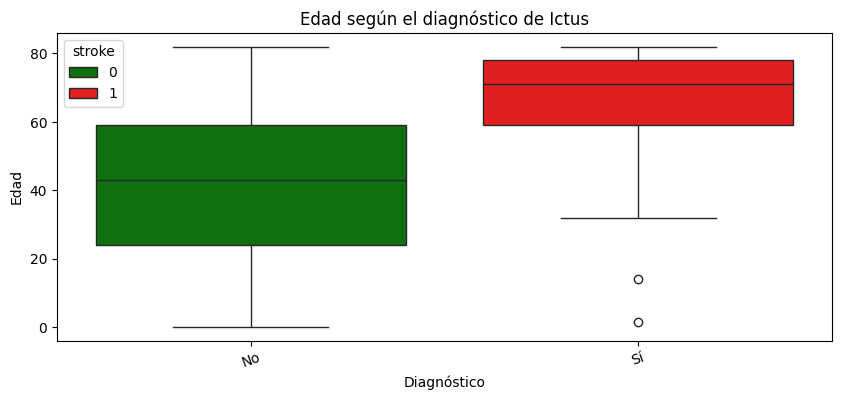

In [ ]:
# Distribuciones boxplot). de age, avg_glucose_level, bmi (histograma
#Caja de bigotes para la edad
#Colores de cajas
colores_cajas = ['Green', 'Red']
#Crear dataframe
plt.figure(figsize=(10, 4))
sns.boxplot(data= df, x='stroke', y='age', hue= 'stroke', palette= colores_cajas)
plt.title('Edad según el diagnóstico de Ictus')
plt.xlabel('Diagnóstico')
plt.ylabel('Edad')
plt.xticks([1,0],['Sí','No'], rotation=20 )
plt.show()


Interpretación:
En este boxplot de edad según el diagóstico, se puede visualizar
que del grupo de personas estudiadas( datatset), el grupo que presenta esta
enfermedad tiene un rango entre 60 a 80 años. La mediana es aproximadamente
de 70 años. En está caja de bigotes(rojo), existen dos outliers, en un rango
de edad entre los 0 a 20 años. Esto es bastante relevante, se deberán
investigar estos dos casos para tomar las medidas necesarias y comprobar si se
tratan de casos reales o son errores de digitación.

#### Caja de bigotes: Nivel promedio de glucosa por Ictus

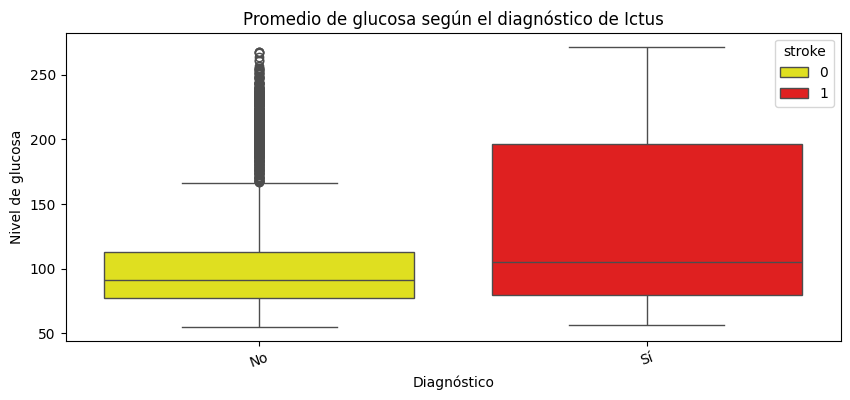

In [ ]:
#Colores de cajas
colores_cajas = ['Yellow', 'Red']
#Crear dataframe
plt.figure(figsize=(10, 4))
sns.boxplot(data= df, x='stroke', y='avg_glucose_level', hue= 'stroke', palette= colores_cajas)
plt.title('Promedio de glucosa según el diagnóstico de Ictus')
plt.xlabel('Diagnóstico')
plt.ylabel('Nivel de glucosa')
plt.xticks([1,0],['Sí','No'], rotation=20 )
plt.show()


Interpretación
Aquí se puede visualizar que en comparación con el diagrama de bigotes anterior
de edad, aquí si hay una mayor incidencia de Ictus por Glucosa. Es decir,
hay más incidencia de Ictus que se relacionan más a los niveles de glucosa que
a la edad.
En este caso, los pacientes con Ictus, presentan niveles de glucosa en rangos entre los 60 y 200 mgl. Además, la mediana se ubica entre 100 mgl
promedio de glucosa.

Por otra parte, en la caja de los pacientes que no presentan Ictus a causa de
los niveles de glucosa, existen demasiados uotliers situados entre niveles de glucosa de más de 150 a más de 250 mgl. Es decir, son personas con niveles muy alterados de glucosa, que corren riesgo de presentar la enfermedad, pero según el estudio al momento no la presentan, por lo que hay que estudiar a profundidad más esos outliners para descartar que sean casos de riesgo de Ictus.

#### Caja de bigotes: IMC según Citus

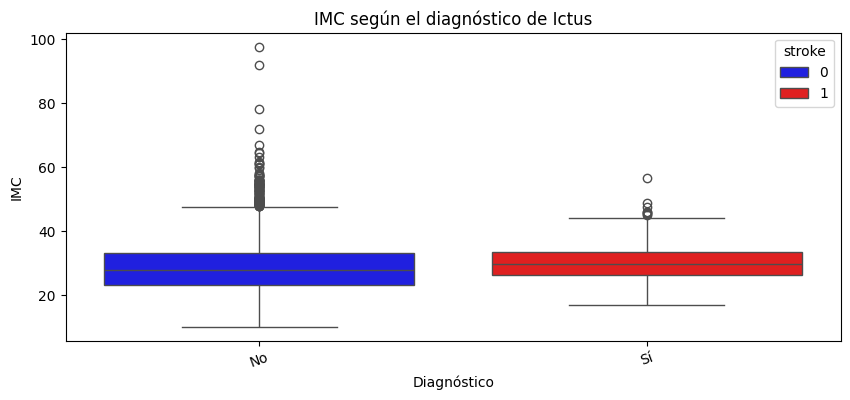

In [ ]:
#Colores de cajas
colores_cajas = ['Blue', 'Red']
#Crear dataframe
plt.figure(figsize=(10, 4))
sns.boxplot(data= df, x='stroke', y='bmi', hue= 'stroke', palette= colores_cajas)
plt.title('IMC según el diagnóstico de Ictus')
plt.xlabel('Diagnóstico')
plt.ylabel('IMC')
plt.xticks([1,0],['Sí','No'], rotation=20 )
plt.show()


Interpretación:
En este caso, el grupo de pacientes que no presenta Ictus según IMC, se
caracteriza por presentar un IMC entre 20 a 40 aproximadamente. Posee una mediana de unos 25 aproximadamente. Existen muchos outliners, 50 y 100 de IMC. Mayormente agrupados entre los 50 y 70 de IMC. Son IMC, muy alterados de riesgos de obesidad, lo cual, es mejor revisar.
Por otro lado, la caja roja de casos comprobados de Ictus, posee una mediana de unos 30 de IMC aproximadamente. Y unos cuantos outliners, a partir del los 50 de IMC.

#### Histograma: Edad

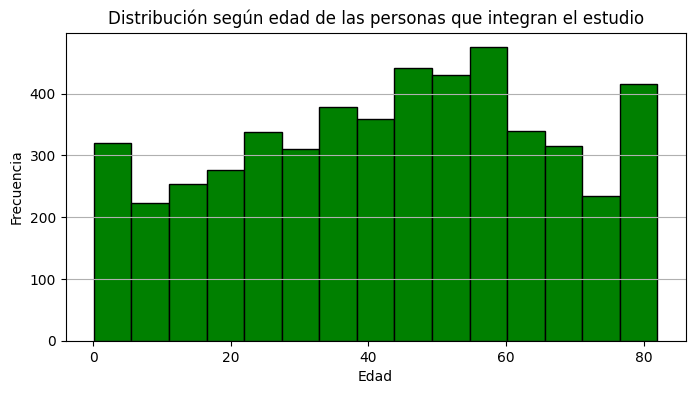

In [ ]:
plt.figure(figsize=(8,4))
plt.hist (df["age"], bins=15, edgecolor= "black", color = "green")
plt.title("Distribución según edad de las personas que integran el estudio")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y")
plt.show()


Interpretación: Este histograma permite ver que los grupos predominantes del estudio son personas que están cerca de los 60 años, los cuales tiene una representación de más de 400 personas. En este caso, ayuda a planificar los servicios y distribuir los recursos de la investigación para estos grupos donde se concentran la mayoría de participantes.

#### Histograma: Nivel promedio de glucosa

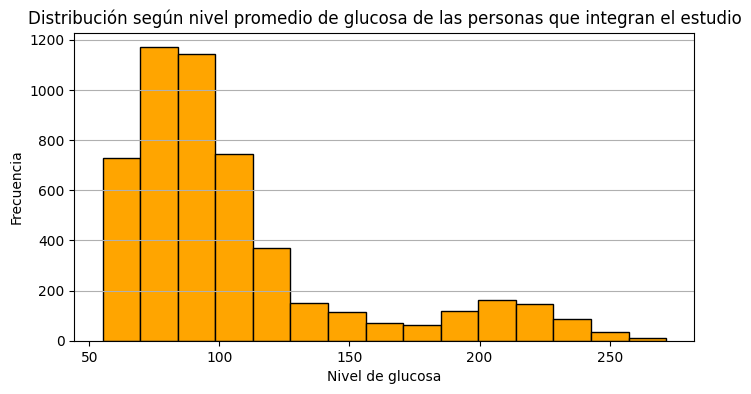

In [ ]:
plt.figure(figsize=(8,4))
plt.hist (df["avg_glucose_level"], bins=15, edgecolor= "black", color = "orange")
plt.title("Distribución según nivel promedio de glucosa de las personas que integran el estudio")
plt.xlabel("Nivel de glucosa")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y")
plt.show()


Interpretación: La mayoría de los participantes de este estudio presentan niveles normales de glucosa. No obstante, se debe prestar atención a aquellos que tienen niveles por encima de los 125 mdl que pueden presentar riesgo de presentar diabetes.

#### Histograma: IMC

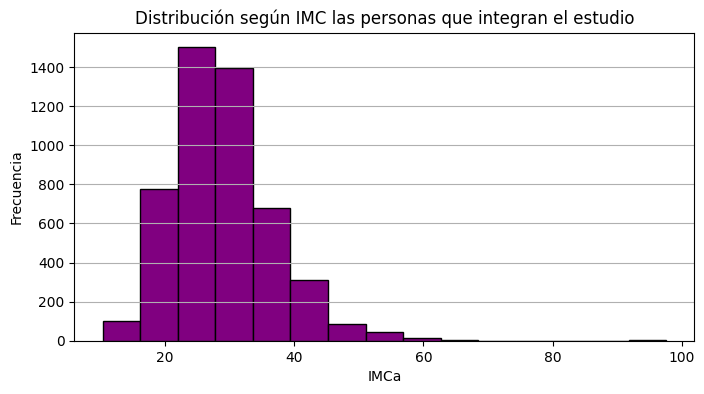

In [ ]:
plt.figure(figsize=(8,4))
plt.hist (df['bmi'], bins=15, edgecolor= "black", color = "purple")
plt.title("Distribución según IMC las personas que integran el estudio")
plt.xlabel("IMCa")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y")
plt.show()


Interpretación: La mayoría de las personas del estudio presentan un IMC entre
los 20 y 40. Habría que estudiar si el IMC, coincide con la estatura y la masa muscular, así como otros factores, debido a qué a partir de los 25 de IMC se considera pre-obesidad.

### 2.Distribución de categóricas (barras)

In [ ]:
#Variables categoricas
variables_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
print('Columnas categóricas:', list(variables_categoricas))


Columnas categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


#### Gráfico de barras: Género

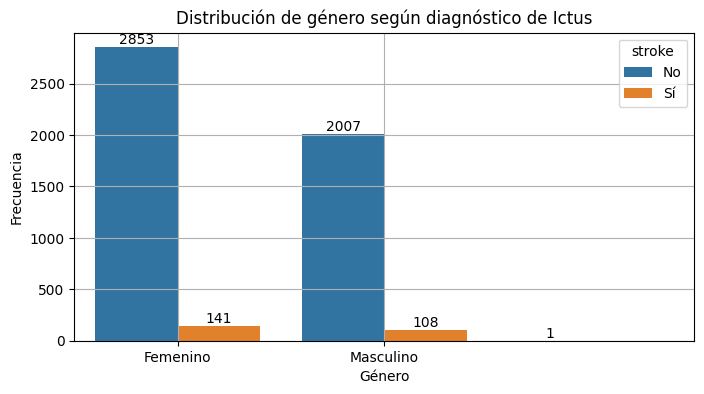

,count
gender,
Female,2994
Male,2115
Other,1


In [ ]:
#Para etiquetas de si presenta o no Ictus
df ['stroke']= df['stroke'].replace({ 0: 'No', 1: 'Sí'})

# Ordenar
df = df.sort_values(by='gender')

#Gráfico de barras
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='gender', hue='stroke')
plt.title('Distribución de género según diagnóstico de Ictus')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.xticks([0,1],['Femenino','Masculino'])
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.grid(True)
plt.show()

#Contar
df['gender'].value_counts()

Interpretación: En el gráfico anterior, se observan tres géneros. Otros sólo posee un participante. Mientras que el género femmenino y masculino poseeen más de dos datos.
Analizando, el género femenino, para un total de 2994, se obtienen que más de 2853 mujeres no presentaron infarto celebral contr 141 mujeres que si fueron diagnósticadas con infarto celebral.
En cuanto, a los hombres, de un total de 2115, 2007 no presentaron infarto celebral contra 108 hombres que si presentaron infarto celebral.
Ambos sexos son propensos a sufrir infartos celebrales.

#### Gráfico de barras: ¿Ha estado casado?

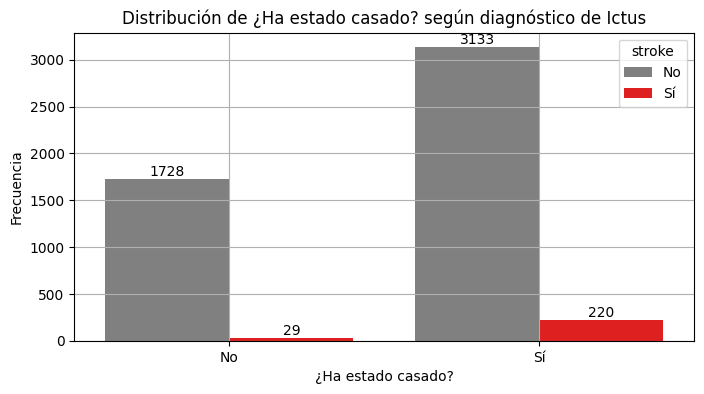

No casados
1.65 %
Casados
6.56 %


In [ ]:
# Grafico de barras seaborn
plt.figure(figsize=(8, 4))
pallete = ['gray', 'red']
ax = sns.countplot(data=df, x='ever_married', hue='stroke', palette= pallete)
plt.title('Distribución de ¿Ha estado casado? según diagnóstico de Ictus')
plt.xlabel('¿Ha estado casado?')
plt.ylabel('Frecuencia')
plt.xticks([0,1],['No','Sí'])
plt.grid(True)
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.show()

print('No casados')
print(round(29/(1728+29)*100, 2), '%')

print('Casados')
print(round(220/(3133+220)*100, 2), '%')

Interpretación: De un total de 1757 personas que no están sacadas, 29 sufrieron derrame celebral. Mientras de un total de 3353 personas que sí han estado casadas, 220 han sufrido derrame cerebral. Es decir, un 1.65% de los no casados fueron diagnósticados con Ictus frente a un 6.56% de casados diagnósticados con Ictus. No obstante, hay que ver que la muestra de casados mayor que la de no casados

#### Gráfico de barras: Tipo de trabajo

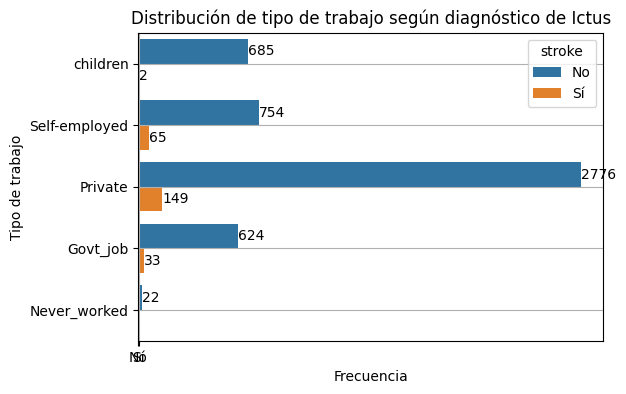

In [ ]:
# Grafico de barras horizontales de tipo de trabajo según diagnostico de Ictus
plt.figure(figsize=(6,4))
ax= sns.countplot(data=df, y='work_type', hue='stroke')
plt.title("Distribución de tipo de trabajo según diagnóstico de Ictus")
plt.xlabel("Frecuencia")
plt.ylabel("Tipo de trabajo")
plt.xticks([0,1],['No','Sí'])
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.grid(True)
plt.show()

Interpretación: Según el gráfico, de los 687 niños del estudio, dos presentan Ictus.
De seguida, los empleados privados suman un total de 2925, de los cuales existen 149 con Ictus; los trabajadores del gobierno, suman un total de 657 personas en estudio, de las cuales 33 presentan Ictus; los personas con empleos a medio tiempo, los cuales son un total de 819, 65 han presentando Ictus; y finalmente, el grupo de personas que nunca trabajaron, según el estudio ninguno ha presentado Ictus.
Hay que ananlizar las situaciones que generan estos datos, por ejemplo, hay grupos con mayor representatividad que otros. Asimismo, se debe analizar a más profundidad, si factores laborales y cuáles de ellos pueden ser un factor que aumenta las probabilidades de presentar Ictus, ya que por ejemplo, el sedentarismo es una causa asociada al Ictus.

#### Gráfico de barras. Tipo residencia

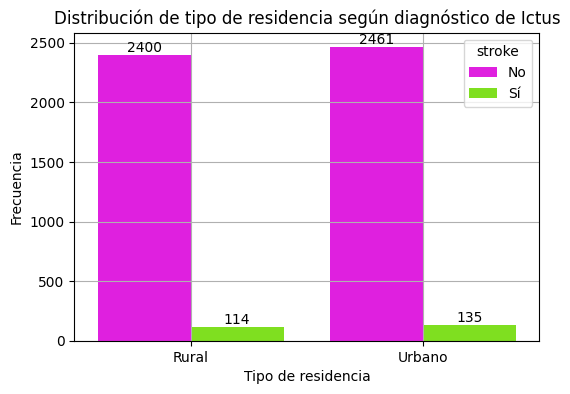

In [ ]:
#'work_type', 'Residence_type', 'smoking_status']
colores = ['magenta', 'chartreuse']
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Residence_type', hue='stroke', palette= colores)
plt.title("Distribución de tipo de residencia según diagnóstico de Ictus")
plt.xlabel("Tipo de residencia")
plt.ylabel("Frecuencia")
plt.xticks([0,1],['Rural','Urbano'])
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.grid(True)
plt.show()

Interpretación: De un total de 2514 personas que habitan en las zonas rurales, 114 han sido diagnósticas con Ictus. Por otro, lado, de 2596 personas en las zonas urbanas 135 han recibido el diagnóstico de qué presentan Ictus.
Hasta el momento, no existen pruebas fuertes de que el ictus este relacionado con el lugar de procedencia.

#### Gráfico de barras: Estado de fumado

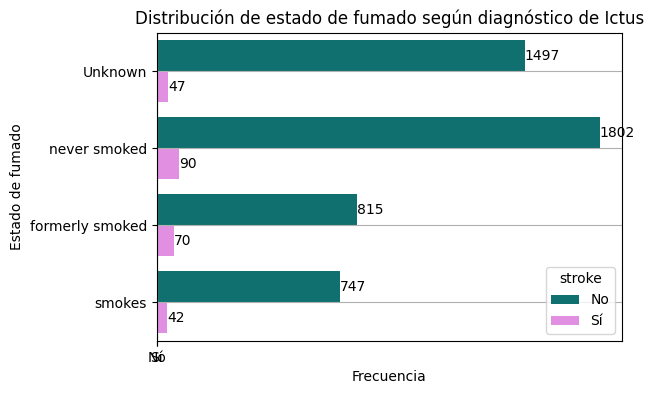

In [ ]:
colores = ['teal', 'violet']
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, y='smoking_status', hue='stroke', palette= colores)
plt.title("Distribución de estado de fumado según diagnóstico de Ictus")
plt.xlabel("Frecuencia")
plt.ylabel("Estado de fumado")
plt.xticks([0,1],['No','Sí'])
plt.grid(True)
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.show()

Interpretación: Según el estudio de 1544 personas desconocidos, 47 si han sido diagnósticados con Ictus; de 1892 que nunca han fumado, 90 han sido diagnósticadas con Ictus; de 885 personas que fueron fumadores y que ya no lo hacen, 70 fueron diagnósticas con Ictus; por último, de 789 fumadores activos, 42 fueron diágnosticados con Ictus.
Se debe hacer enfásis en que el fumado se encuentra entre los factores de riesgo asociados al diagnóstico de Ictus.

### 3.Discusión de desbalance de stroke y su implicación

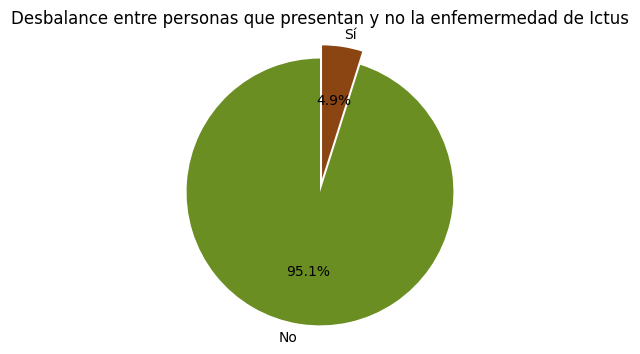

In [ ]:
# Contar casos de STROKE
contar_casos = df['stroke'].value_counts()
# Explode
explode = (0.1, 0)
# Crear pie chart
plt.figure(figsize=(8, 4))
plt.pie(contar_casos, labels=contar_casos.index, autopct='%1.1f%%',
colors= ['olivedrab', 'saddlebrown'], explode= explode, startangle= 90)
plt.title('Desbalance entre personas que presentan y no la enfemermedad de Ictus')
plt.axis('equal')
plt.show()


De un total de 5510 personas que forman este estudio, 4861 no han sido diagnósticads con Ictus y 249 si han sido diagnósticas con esta enfermedad.
Es decir, un 95.1%, representado en color oliva en el gráfico no ha sido diagnósticado con Ictus, y el 4.9%, si ha sido diagnósticado con Ictus.

### 4.Generar reporte

In [ ]:
# Reporte EDA
#Diicionario
reporte= {"Descripción": df.describe(),
 "Primeros 5": df.head(),
 "Últimos 5": df.tail(),
 "Suma de nulos": df.isnull().sum(),
 "Suma de duplicados": df.duplicated().sum()
 }
df.info()

#Guardar en CVS
reporte["Descripción"].to_csv("reporte_describe.csv")
reporte["Primeros 5"].to_csv("reporte_head.csv")
reporte["Últimos 5"].to_csv("reporte_tail.csv")
reporte["Suma de nulos"].to_csv("reporte_isnull_sum.csv")


print("Reporte EDA ha sido guardado")

<class 'pandas.core.frame.DataFrame'>
Index: 5110 entries, 2554 to 3116
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5110 non-null   int64  
 1   gender              5110 non-null   object 
 2   age                 5110 non-null   float64
 3   hypertension        5110 non-null   int64  
 4   heart_disease       5110 non-null   int64  
 5   ever_married        5110 non-null   object 
 6   work_type           5110 non-null   object 
 7   Residence_type      5110 non-null   object 
 8   avg_glucose_level   5110 non-null   float64
 9   bmi                 4909 non-null   float64
 10  smoking_status      5110 non-null   object 
 11  stroke              5110 non-null   object 
 12  valor_imputado      5110 non-null   float64
 13  windowizar_bmi      5110 non-null   float64
 14  windowizar_glucosa  5110 non-null   float64
dtypes: float64(6), int64(3), object(6)
memory usage: 638.8+ K

Se ha realizado un análisis EDA que integra la descripción de los datos, tanto los primeros como los últimos cinco registros, aspi como la suma de los valores nulos y los duplicados. Y finalmente los tipos de datos.

## EJERCICIO 4. Asociaciones con el objetivo “Stroke”

Construir tablas y gráficos comparando stroke vs:
• hypertension, heart_disease (tasas y riesgos relativos simples).
• Residence_type, work_type, smoking_status (tasas por categoría).
• age (curva de tasa por bins).
+
Pasos sugeridos en Python (bibliotecas)
• pandas.groupby y agregaciones.  
• Visualizaciones: barras con tasa (media de stroke por grupo).

### 1.Comparativo: ICTUS & HIPERTENSIÓN


 ICTUS & HIPERTENSIÓN

Frecuencias:
 stroke              No        Sí
hypertension                    
0             0.960321  0.039679
1             0.867470  0.132530

Porcentajes por diagnóstico (%):
 stroke           No     Sí
hypertension              
0             96.03   3.97
1             86.75  13.25


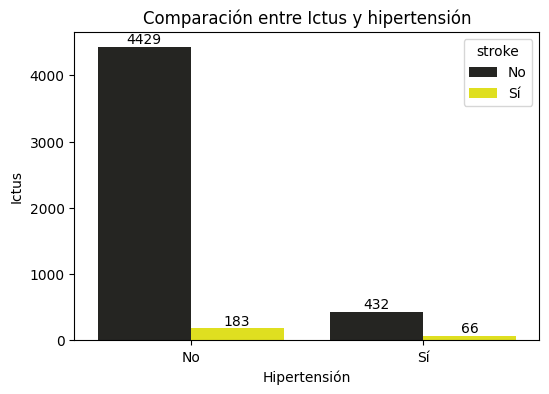

In [ ]:
print('\n ICTUS & HIPERTENSIÓN\n')
# Tabla comparación stroke entre hypertension
tabla_hipertension = pd.crosstab(df['hypertension'], df['stroke'], normalize= 'index')
tabla_porcentaje = tabla_hipertension.div(tabla_hipertension.sum(axis=1), axis=0) * 100
print("Frecuencias:\n", tabla_hipertension.head())
print("\nPorcentajes por diagnóstico (%):\n", tabla_porcentaje.round(2).head())

# Grafico comparación entre stroke y hypertension
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='hypertension', hue='stroke', palette='dark:yellow')
plt.title('Comparación entre Ictus y hipertensión')
plt.xlabel('Hipertensión')
plt.ylabel('Ictus')
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.xticks([0,1],['No','Sí'])
plt.show()


Interpretación: Existen 4429 personas en el estudio que no son hipertensas y no han tenido Ictus. Mientras hay 183 que no son hipertensas, pero si hay sido diagnósticadas con Ictus.
Por otra parte, existen 432 personas hipertensas que no han presentado Ictus y 66 que son hipertensas y han tenido Ictus.
De los participantes sin hipertensión 3.97 % ha sido diagnósticada con Ictus y de los participantes con hipertensión, solo el 13.25% ha sido diagnósticada con Ictus.
 Esto muestra que existe una proporción mayor de Ictus en las personas hipertensas, en comparación, con los que no son hipertensas. Es decir, puede haber una relación entre la hipertensión y el Ictus.


### 2.Comparativo: ICTUS & ENFERMEDADES CARDIOVASCULARES


 ICTUS & ENFERMEDADES CARDIOVASCULARES

Tabla comparativa: Ictus & Enfermdedades cardiovasculares 

Frecuencias:
 stroke               No        Sí
heart_disease                    
0              0.958213  0.041787
1              0.829710  0.170290

Porcentajes por diagnóstico (%):
 stroke            No     Sí
heart_disease              
0              95.82   4.18
1              82.97  17.03


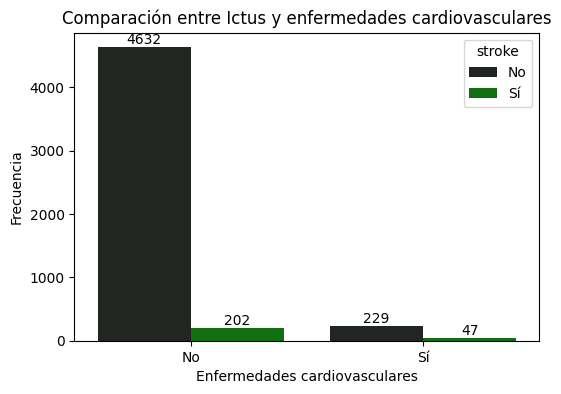


Con problemas cardíacos
17.03 %
Sin problemas cardícos
4.18 %


In [ ]:
print('\n ICTUS & ENFERMEDADES CARDIOVASCULARES\n')

# Grafico comparando stroke y heart_disease( tasas y riesgos relativos simples)
print('Tabla comparativa: Ictus & Enfermdedades cardiovasculares \n')
tabla_enfer_corazon = pd.crosstab(df['heart_disease'], df['stroke'], normalize= 'index')
tabla_porcentaje = tabla_enfer_corazon.div(tabla_enfer_corazon.sum(axis=1), axis=0) * 100
print("Frecuencias:\n",tabla_enfer_corazon.head())
print("\nPorcentajes por diagnóstico (%):\n", tabla_porcentaje.round(2).head())


# Grafico comparativo:Ictus & enfermedades cardiovasculares
plt.figure(figsize=(6, 4))
ax= sns.countplot(data=df, x='heart_disease', hue='stroke', palette='dark:green')
plt.title('Comparación entre Ictus y enfermedades cardiovasculares')
plt.xlabel('Enfermedades cardiovasculares')
plt.ylabel('Frecuencia')
plt.xticks([0,1],['No','Sí'])
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.show()

#Cálculo de porcentajes
print('\nCon problemas cardíacos')
print(round(47/(47+229)*100,2), '%')
print('Sin problemas cardícos')
print(round(202/(202+4632)*100, 2), '%')

Interpretación: Existen 4632 personas en el estudio que no han presentado problemas cardíacos y ni Ictus. Luego, hay 202 que no han presentado problemas cardíacos, pero si han sido diagnósticados con Ictus.

Seguidamente, se reportan 229 personas con problemas cardíacos que no han presentado Ictus y 47 que presentan problemas cardíacos y Ictus.

De los participantes con problemas cardíacos el 17.03% ha sido diagnosticado con Ictus y de los participantes sin problemas cardíacos el 4.18% ha tenido Ictus. Esto evidencia que existe una proporción mayor de Ictus en las personas con problemas cardíacos, en comparación, con los que no tienen problemas cardíacos. Es decir, puede haber una relación positiva entre la los problemas cardíacos y el Ictus.


### 3.Comparativo: ICTUS & TIPO DE RESIDENCIA


 ICTUS & TIPO DE RESIDENCIA

Frecuencias:
 stroke                No        Sí
Residence_type                    
Rural           0.954654  0.045346
Urban           0.947997  0.052003

Porcentajes por diagnóstico (%):
 stroke             No    Sí
Residence_type             
Rural           95.47  4.53
Urban           94.80  5.20


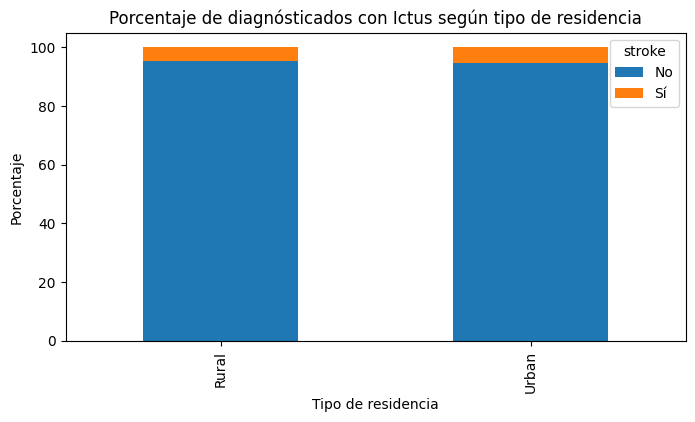

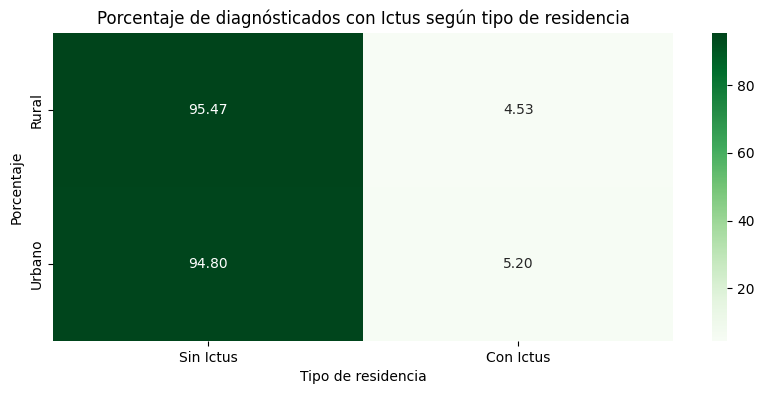


Zona rural
0.05 %
Zona urbana
0.05 %


In [ ]:
print('\n ICTUS & TIPO DE RESIDENCIA\n')
tabla_residencia = pd.crosstab(df['Residence_type'], df['stroke'], normalize= 'index')
tabla_porcentaje = tabla_residencia.div(tabla_residencia.sum(axis=1), axis=0) * 100
print("Frecuencias:\n",tabla_residencia.head())
print("\nPorcentajes por diagnóstico (%):\n", tabla_porcentaje.round(2).head())

#Gráfico de barras
tabla_porcentaje.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.title('Porcentaje de diagnósticados con Ictus según tipo de residencia')
plt.xlabel('Tipo de residencia')
plt.ylabel('Porcentaje')
plt.show()

print('\n')
#Grafico heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(tabla_porcentaje, cmap = 'Greens', annot=True, fmt='.2f')
plt.title('Porcentaje de diagnósticados con Ictus según tipo de residencia')
plt.xlabel('Tipo de residencia')
plt.ylabel('Porcentaje')
plt.yticks([0.5,1.5],['Rural','Urbano'])
plt.xticks([0.5,1.5], ['Sin Ictus','Con Ictus'])
plt.show()

#Porcentajes
print('\nZona rural')
print(round(4.53/95.47,2), '%')
print('Zona urbana')
print(round(5.20/94.80, 2), '%')

Interpretación: De las personas que viven en zonas rurales un 95.47% personas  no han sido diagnosticadas con Ictus, frente a un 4.53% que si ha sido diagnosticada con esta enfermedad.

Por otra parte, de las personas que viven en zonas urbanas, un 94.80% no ha sido diagnosticada con Ictus, mientras que un  5.20% si ha presentado.

Es decir, en ambas zonas el 0.05% han presentado Ictus. Evidenciando, que las zonas (rurales o urbanas) no tienen aparente causa de incidencia en relación con el Ictus.

### 4.Comparativo: ICTUS & TIPO DE TRABAJO


 ICTUS & TIPO DE TRABAJO

Frecuencias:
 stroke               No        Sí
work_type                        
Govt_job       0.949772  0.050228
Never_worked   1.000000  0.000000
Private        0.949060  0.050940
Self-employed  0.920635  0.079365
children       0.997089  0.002911

Porcentajes por diagnóstico (%):
 stroke             No    Sí
work_type                  
Govt_job        94.98  5.02
Never_worked   100.00  0.00
Private         94.91  5.09
Self-employed   92.06  7.94
children        99.71  0.29


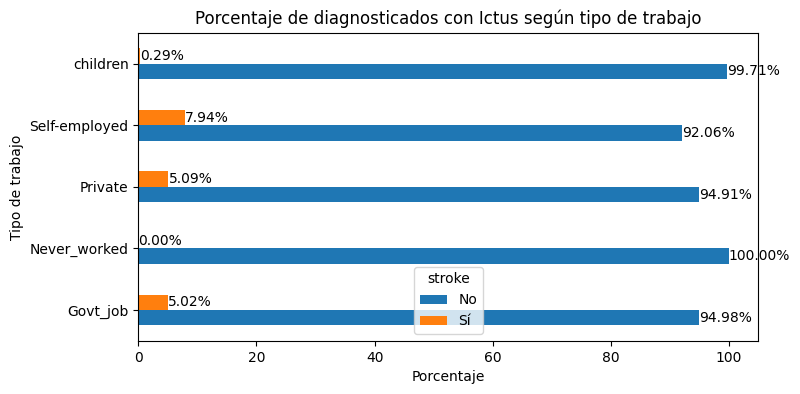


Medio tiempo
0.09 %


In [ ]:
print('\n ICTUS & TIPO DE TRABAJO\n')
#Tabla
tabla_trabajo = pd.crosstab(df['work_type'], df['stroke'], normalize='index')
tabla_porcentaje = tabla_trabajo * 100
print("Frecuencias:\n", tabla_trabajo.head())
print("\nPorcentajes por diagnóstico (%):\n", tabla_porcentaje.round(2).head())

#Gráfico
ax= tabla_porcentaje.plot(figsize=(8, 4), kind='barh', stacked=False)
plt.title('Porcentaje de diagnosticados con Ictus según tipo de trabajo')
plt.xlabel('Porcentaje')
plt.ylabel('Tipo de trabajo')
ax.bar_label(container=ax.containers[0], fmt ='%.2f%%')
ax.bar_label(container=ax.containers[1], fmt = '%.2f%%')
plt.show()

print('\nMedio tiempo')
print(round(7.94/92.06, 2), '%')

Interpretación: Según el tipo de trabajo: trabajo en el gobierno, nunca han trabajado, privado, a medio tiempo o niños. Los que no han sido diagnosticados con Ictus superan el 92% en todos los grupos. Mientras, los que si han sido diagnosticados con Ictus, se mantienen entre 0% a un 8% entre los grupos, lo cual no es significativo.

Por ejemplo, en el caso del trabajo a medio tiempo, un 92.06% no ha presentado Ictus y un 7.94% si ha sido diagnosticado con esta enfermedad. Es decir, en ese grupo sólo un 0.09 % presenta Ictus. Por lo cual, se llega a la conclusión que el tipo de trabajo no influye tanto en la presencia de Ictus.

### 5.Comparativo: ICTUS & ESTADO DE FUMACIÓN


 ICTUS & ESTADO DE FUMACIÓN

Frecuencias:
 stroke                 No        Sí
smoking_status                     
Unknown          0.969560  0.030440
formerly smoked  0.920904  0.079096
never smoked     0.952431  0.047569
smokes           0.946768  0.053232

Porcentajes por diagnóstico (%):
 stroke              No    Sí
smoking_status              
Unknown          96.96  3.04
formerly smoked  92.09  7.91
never smoked     95.24  4.76
smokes           94.68  5.32


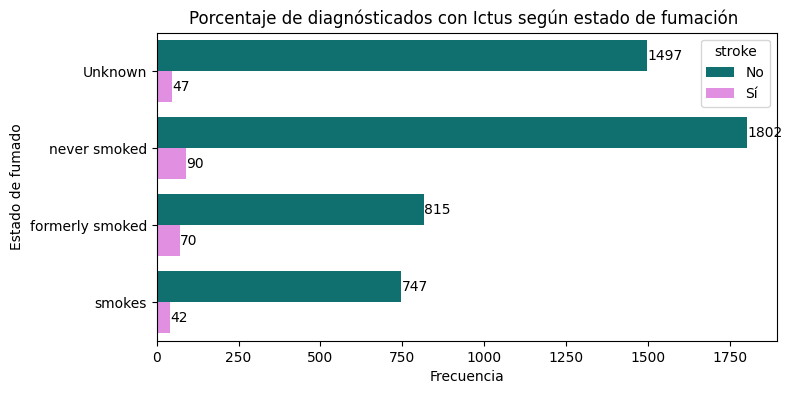

In [ ]:
print('\n ICTUS & ESTADO DE FUMACIÓN\n')
#Grafico comparción smoking_status (tasas por categorias) con stroke
tabla_estadoFumado = pd.crosstab(df['smoking_status'], df['stroke'], normalize= 'index')
tabla_porcentaje = tabla_estadoFumado.div(tabla_estadoFumado.sum(axis=1), axis=0) * 100
print("Frecuencias:\n",tabla_estadoFumado.head())
print("\nPorcentajes por diagnóstico (%):\n", tabla_porcentaje.round(2).head())

colores= ['teal', 'violet']
#Gráfico comparativo
plt.figure(figsize=(8, 4))
ax= sns.countplot(data=df, y='smoking_status', hue='stroke', palette= colores)
plt.title('Porcentaje de diagnósticados con Ictus según estado de fumación ')
plt.xlabel('Frecuencia')
plt.ylabel('Estado de fumado')
ax.bar_label(container=ax.containers[0])
ax.bar_label(container=ax.containers[1])
plt.show()

Interpretación: En el grupo de los que anteriormente fumaban un 3.04% son diagnosticados con Ictus, los que nunca fumaron un 4.76% han sido diagnosticados con Ictus, los que fuman un 5.32% fueron diagnosticados con Ictus y los que se desconoce le estado de fumado un 3.04% tuvieron ese diagnostico. Es decir, los que fuman tienen el porcentaje más alto de todos los grupos, lo que podría indicar que el fumado si tiene una relación positica como causante de Ictus.

### 6.Comparativo:ICTUS & EDAD


 ICTUS & EDAD



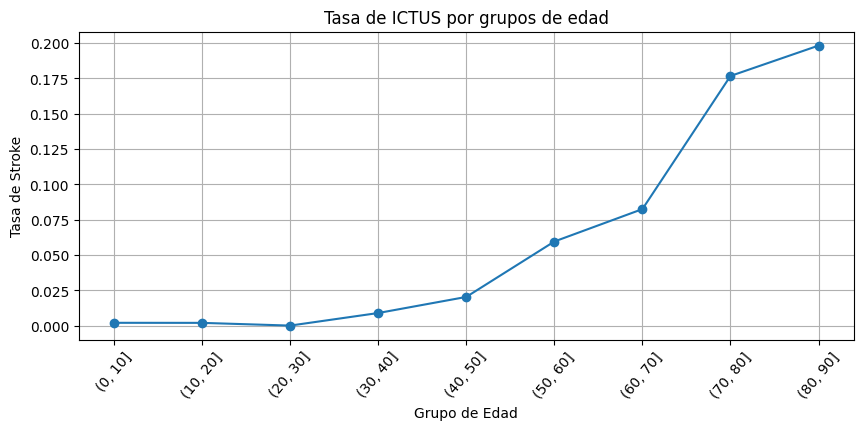

In [ ]:
print('\n ICTUS & EDAD\n')

#Bins de edad
df["grupo_etario"] = pd.cut(df["age"], bins=range(0, 101, 10))

# Convertir stroke a valores numéricos
df['stroke'] = df['stroke'].map ({'Sí':1, 'No': 0})

#Calcular tasa de stroke por grupo de edad
tasa_edad = df.groupby("grupo_etario", observed=True)["stroke"].mean()

#Gráfico: curva de tasa
plt.figure(figsize=(10, 4))
tasa_edad.plot(kind="line", marker="o")
plt.title("Tasa de ICTUS por grupos de edad")
plt.ylabel("Tasa de Stroke")
plt.xlabel("Grupo de Edad")
plt.xticks(rotation=50)
plt.grid(True)
plt.show()

Interpretación: En este gráfico lineal se puede ver el comportamiento del Ictus según la edad.

 En conclusión, entre más edad más riego de presentar ICTUS.

## EJERCICIO 5.  Imputación de BMI: comparación de 3 estrategias y su impacto

Se sabe que en este dataset se reportan “n” datos faltantes en BMI.
Comparar 3 estrategias (deberá investigar lo siguiente):
1. Eliminar filas con BMI faltante (listwise deletion).
2. SimpleImputer(strategy="median").  
3. KNNImputer(n_neighbors=k) para BMI (y/o numéricas).  
Luego, entrenar un modelo baseline constante (p. ej., regresión logística)
con el mismo pipeline y comparar métricas.
Pasos sugeridos en Python (bibliotecas)
• sklearn.impute.SimpleImputer, KNNImputer.  
• Pipeline y ColumnTransformer

--------Estrategia 1---------
         id  gender   age  hypertension  heart_disease ever_married work_type  \
2554  72369  Female  14.0             0              0           No  children   
3008    563  Female  41.0             0              0          Yes   Private   
3009  19364  Female   7.0             0              0           No  children   
3011  55459  Female  60.0             0              0           No   Private   
3012  38724  Female  49.0             1              0          Yes  Govt_job   

     Residence_type  avg_glucose_level   bmi   smoking_status  stroke  \
2554          Rural              65.41  19.5          Unknown       0   
3008          Rural             216.71  36.2     never smoked       0   
3009          Rural              74.96  18.8          Unknown       0   
3011          Rural              91.82  28.3  formerly smoked       0   
3012          Urban              56.37  39.4           smokes       0   

      valor_imputado  windowizar_bmi  window

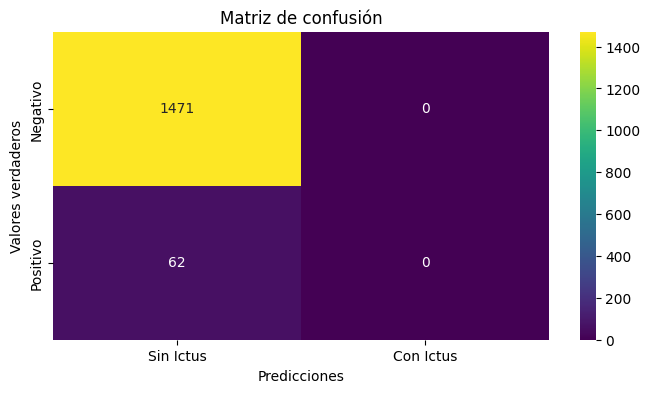

In [ ]:
#Importar biblioteca
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

#Para modelo logistico
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
#Para matriz de confusión
from sklearn.metrics import confusion_matrix

#1.Estrategia. Eliminar filas con BMI faltante (listwise deletion)
print("--------Estrategia 1---------")
eliminarFilasBMI = df.dropna(subset=['bmi'])
print(eliminarFilasBMI.head())

#2. Estrategia. SimpleImputer (strategy= "median")
print("--------Estrategia 2---------")
imputarSimple = SimpleImputer(strategy= "median")
imputarSimple_BMI = imputarSimple.fit_transform(df[['bmi']])
print(imputarSimple_BMI)

#3. Estrategia. KNNImputer(n_neighbors=k) para BMI (y/o numéricas)
print("--------Estrategia 3---------")
imputarKNNI = KNNImputer(n_neighbors=5)
imputarKNNI_BMI = imputarKNNI.fit_transform(df[['bmi']])
print(imputarKNNI_BMI)

#Entrenar un modelo baseline constante( ej. regresion losgistica) con el mismo pipeline y comparar metricas
# Imputar los valores que faltan en bmi
imputar= SimpleImputer(strategy= "median")
df[['bmi']] = imputar.fit_transform(df[['bmi']])
y = df['stroke']

# Definir variables
x = df[['bmi']]
y = df['stroke']

#Dividir en train/test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#Modelo baseline ( regresión logística)
modelo = LogisticRegression()
modelo.fit(x_train, y_train)
y_pred = modelo.predict(x_test)

#Metricas
print("--------Metricas---------")
accuracy = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy)

#Matriz de confusión
print("--------Matriz de confusión---------")
matriz_Confusion = confusion_matrix(y_test, y_pred)
print(matriz_Confusion)

#Gráfico de heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(matriz_Confusion, cmap = 'viridis', annot=True, fmt='d')
plt.title('Matriz de confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores verdaderos')
plt.yticks([0.5,1.5],['Negativo','Positivo'])
plt.xticks([0.5,1.5], ['Sin Ictus','Con Ictus'])
plt.show()

Interpretación:
La primera estrategia consiste en eliminar los datos faltantes (NaN) del IMC.

La segunda estrategia es un SimpleImputer con mediana, este proceso permite rellenar los valores que faltan usando valores acorde a la mediana, lo que evita valores extremos.

La tercera estrategia es imputar con KNNI, aquí se usa los k= 5 más cercanos para calcular los valores faltantes.

Luego viene lo que es el entrenamiento con el modelo baseline, utilizando el SimpleImputer y creando un modelo de regresión logística. La regresión logística es ideal para valores binarios, en este caso stroke es 0 o 1.
Luego con la exactitud se obtiene un 0,94 (94%) de proporción de predicciones correctas.

Para evaluar si esa proporción es correcta, se realiza una matriz de confusión.
Esta arroja 1444 verdadero negativos ( paciente sin Ictus clasificados correctamente), 0 falsos positivos(personas sin Ictus clasificados con Ictus), 89 falsos negativos (pacientes con Ictus clasificados sin Ictus) y 0 verdaderos positivos ( personas con Ictus clasificados con Ictus).


## EJERCICIO 6. Binning de edad y análisis de tasas por grupo etario

Objetivo de aprendizaje (competencias)
Transformar una variable numérica en categorías (bins) y analizar métricas
de salud por grupo.
Descripción
Crear grupos de edad (p. ej., 0–20, 21–40, 41–60, 61–80) y calcular tasa
de stroke por grupo. Este tipo de análisis aparece en investigaciones que
exploran imputación por grupos etarios.  
Pasos sugeridos en Python (bibliotecas)
• pandas, groupby.
• Visualización: barras ordenadas.

Porcentajes
grupo_etario
0-20     20.1
21-40    23.9
41-60    30.6
61-80    23.2
80+       2.3
Name: proportion, dtype: float64
grupo_etario
0-20     0.00
21-40    0.00
41-60    0.04
61-80    0.13
80+      0.20
Name: stroke, dtype: float64


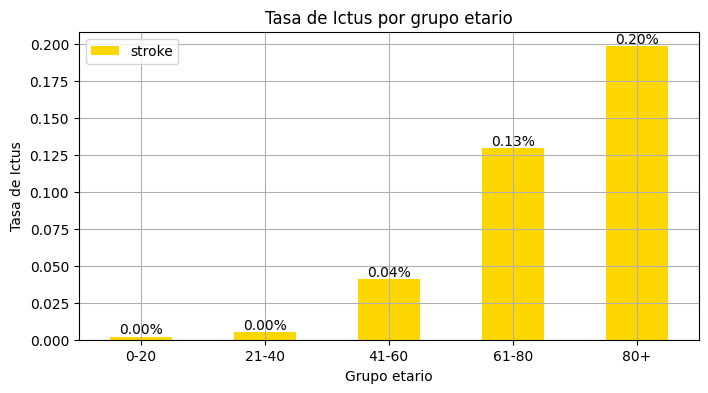

In [ ]:
# Crear grupos de edad (0-20-21-40-41-60-61-80)
edades = [0,20, 40, 60, 80, 100]
grupos_etarios = ['0-20','21-40','41-60','61-80', '80+']

#Transformar una variable numerica en categorias bins
df['grupo_etario'] = pd.cut(df['age'], bins=edades, labels= grupos_etarios,include_lowest=True, right= True)

#Crear porcentajes
print('Porcentajes')
pct = df["grupo_etario"].value_counts(normalize=True).sort_index() * 100
print(pct.round(1))

#Covertir stroke a numerica
df['stroke'] = pd.to_numeric(df['stroke'])

#Calcular tasa de stroke por grupo
tasa = df.groupby('grupo_etario', observed=True)['stroke'].mean()
print(tasa.round(2))

#Visualizacion: barras ordenadas
plt.figure(figsize=(8, 4))
ax = tasa.plot(kind='bar', color= "gold")
plt.title('Tasa de Ictus por grupo etario')
plt.xlabel('Grupo etario')
plt.ylabel('Tasa de Ictus')
plt.xticks(rotation=0)
plt.legend()
ax.bar_label(container=ax.containers[0], fmt= '%.2f%%')
plt.grid(True)
plt.show()

Interpretación: De acuerdo con el gráfico, el grupo etario con mayor tasa de Ictus es el grupo con edades de más de 80 años con un 0.20%, seguido con un 0.13% por el grupo de 61 a 80 años, y en una tercera posición con un porcentaje de 0.04% se encuentra el grupo de entre 41 a 60 años de edad.

Los grupos con la menor tasa de derrame celebral, son los grupos de 0 a 21 y 21 a 40 años de edad. En base a esto, se puede afirmar que la edad es un factor relevante de riesgo en las tasas de derrame celebral. Entre mayor edad más riesgo de Ictus.

## EJERCICIO 7. Outliers en glucosa y BMI: detección, tratamiento y efecto en modelos

Objetivo de aprendizaje (competencias)
Detectar outliers (IQR/z-score), aplicar estrategias (clipping/winsorizing)
para manejar valores atípicos y medir impacto (Deberá investigar).
Descripción  
1. Detectar outliers en avg_glucose_level y bmi (boxplots). Estudios
reportan presencia de outliers en estas numéricas.  
2. Comparar: sin tratamiento vs clipping percentil 1–99.
3. Entrenar modelo baseline y comparar métricas.

### 1.Detectar outliers en avg_glucose_level y bmi (boxplots). Estudios reportan presencia de outliers en estas numéricas.

#### 1.1. Outliners nivel promedio glucosa


 Niveles promedio de glucosa 

Q1: 77.245
Q3: 114.09
Rango intercuartílico: 36.845

 Cantidad de outliners en nivel de glucosa 
          id  gender   age  hypertension  heart_disease ever_married  \
3008    563  Female  41.0             0              0          Yes   
3014  35716  Female  55.0             1              0          Yes   
2981  69329  Female  62.0             0              0          Yes   
2992  52236  Female  60.0             0              0          Yes   
3130  34400  Female  77.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
3148   6032    Male  78.0             0              0          Yes   
3150  69979    Male  73.0             0              0          Yes   
3152  20094    Male  54.0             1              0          Yes   
1166  33622    Male  62.0             1              0          Yes   
3161  51554    Male  42.0             0              0          Yes   

          work_ty

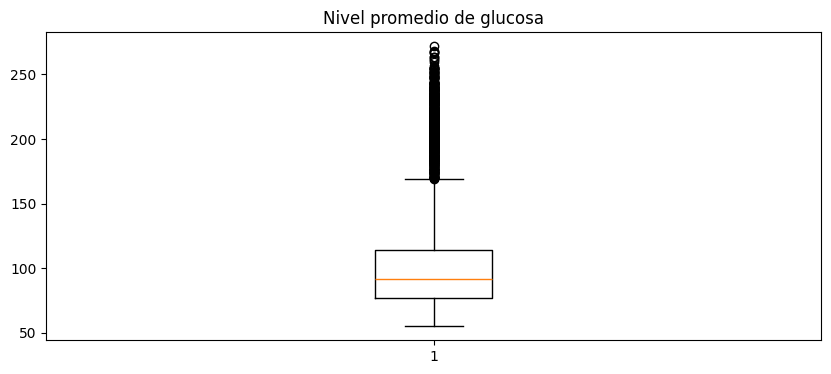

In [ ]:
#Nivel promedio de glucosa
#Outliners
Q1= df['avg_glucose_level'].quantile(0.25)
Q3= df['avg_glucose_level'].quantile(0.75)
IQR= Q3-Q1

print('\n Niveles promedio de glucosa \n')
print('Q1:', Q1)
print('Q3:', Q3)
print('Rango intercuartílico:', IQR)

#Límites inferiores y superiores
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR
outliers_niveles_glucosa = df[df['avg_glucose_level'] < limite_inferior]
outliers_niveles_glucosa = df[df['avg_glucose_level'] > limite_superior]
print('\n Cantidad de outliners en nivel de glucosa \n', outliers_niveles_glucosa)

# Gráfico para el nivel de glucosa
plt.figure(figsize=(10, 4))
plt.boxplot(df['avg_glucose_level'])
plt.title('Nivel promedio de glucosa')
plt.show()

Interpretación: El Q1 es de 77.25, el Q3 es de 114.09 y el rango intercuartílico es de 36.85.

Es decir, el 25% mínimo de los niveles de glucosa es de 77.25. Mientras que el 25% máximo de los niveles de glucosa es de 114.09.

El rango intercuartículo, indica una media (en este caso la línea naranja que se ilustra en el gráfico, la cual es de 36.85 mg/dL).

Tomando de referencia el gráfico, existen niveles fuera de rango entre niveles de glucosa de más de 150 y más de 250 mg/dL.

#### 1.2. Outliners de BMI


 Niveles de BMI 

Q1 23.8
Q3 32.8
IQR: 8.999999999999996

 Cantidad de outliners en BMI 
          id  gender   age  hypertension  heart_disease ever_married  \
3024  69834  Female  57.0             0              0          Yes   
2764  20292  Female  24.0             0              0          Yes   
2840  65895  Female  52.0             0              0          Yes   
2883   4793  Female  60.0             1              0          Yes   
3508  65154  Female  30.0             0              0          Yes   
...     ...     ...   ...           ...            ...          ...   
1267  43088    Male  37.0             0              0           No   
3060  32604    Male  49.0             0              0          Yes   
2893  52164    Male  29.0             0              0          Yes   
2896  43837    Male  33.0             0              0          Yes   
3218  41146    Male  41.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   

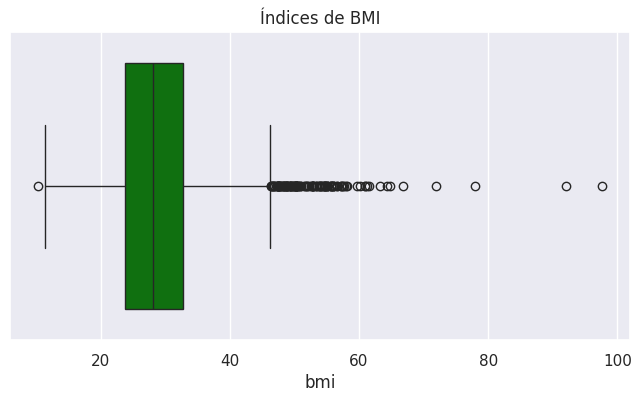

In [ ]:
#BMI
# Detectar outliners en BMI
Q1= df['bmi'].quantile(0.25)
Q3= df['bmi'].quantile(0.75)
IQR= Q3-Q1
print('\n Niveles de BMI \n')
print('Q1',Q1)
print('Q3', Q3)
print('IQR:', IQR)

#Límites inferiores y superiores
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR
outliers_bmi = df[df['bmi'] < limite_inferior]
outliers_bmi = df[df['bmi'] > limite_superior]
print('\n Cantidad de outliners en BMI \n', outliers_bmi)

# Boxplot de BMI
sns.set_theme()
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['bmi'], color="green")
plt.title('Índices de BMI')
plt.show()


#################################################

Interpretación: El Q1 es de 23.8, el Q3 es de 32.8 y el rango intercuartílico es de 9.

Es decir, el 25% mínimo de los IMC es de 23.8 (IMC:Normal). Mientras que el 25% máximo es de 32.8(IMC:Obesidad).

El rango intercuartículo, indica una media (en este caso la línea naranja que se ilustra en el gráfico, la cual es de 9). Tomando de referencia el gráfico, existen valores fuera de rango entre los 50 y más de 100 de IMC.

### 2.Comparar: sin tratamiento vs clipping percentil 1–99.

#### 2.1.Comparar nivel de glucosa: sin tratamiento vv clipping percentil 1-99

Percentil 1: 56.33
Percentil 99 240.71
         id  gender   age  hypertension  heart_disease ever_married  \
2554  72369  Female  14.0             0              0           No   
3007   3135  Female  73.0             0              0           No   
3008    563  Female  41.0             0              0          Yes   
3009  19364  Female   7.0             0              0           No   
3011  55459  Female  60.0             0              0           No   
...     ...     ...   ...           ...            ...          ...   
1166  33622    Male  62.0             1              0          Yes   
3161  51554    Male  42.0             0              0          Yes   
3162   2296    Male  78.0             1              0          Yes   
1183  13602    Male  73.0             1              0          Yes   
3116  56156   Other  26.0             0              0           No   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
2554       children         

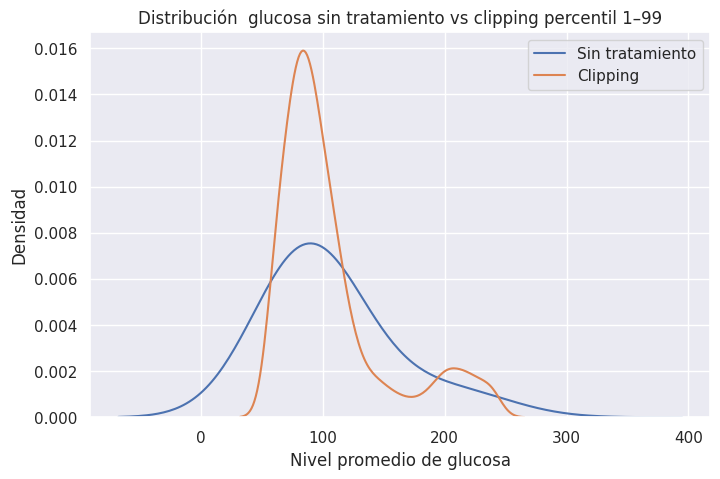

In [ ]:
#2. Comparar: sin tratamiento vs clipping percentil 1–99.

#Calcular percentil de glucosa
p1_Glucosa =  np.percentile(df["avg_glucose_level"], 1)
p99_Glucosa = np.percentile(df["avg_glucose_level"], 99)

#Aplicar cippling/ winsorizing
cippling_glucosa = df.copy()
cippling_glucosa['avg_glucose_level'] = cippling_glucosa['avg_glucose_level'].clip(p1_Glucosa, p99_Glucosa)

print('Percentil 1:', round(p1_Glucosa,2))
print('Percentil 99', round(p99_Glucosa, 2))
print(cippling_glucosa)

# Gráfico de glucosa
plt.figure(figsize=(8,5))
sns.kdeplot(df['avg_glucose_level'], label='Sin tratamiento', bw_adjust= 5)
sns.kdeplot(cippling_glucosa['avg_glucose_level'], label='Clipping')
plt.title('Distribución  glucosa sin tratamiento vs clipping percentil 1–99')
plt.xlabel('Nivel promedio de glucosa')
plt.ylabel('Densidad')
plt.legend()
plt.show()


Interpretación:
Los percentiles en las glucosas son:

Percentil 1:  (56.30)

Percentil 99: ( 240.71)

Esto quiere decir que, menos de un 1% de los participantes del estudio tiene niveles promedio de glucosa de 56.33. Es un valor muy bajo, hipoglucemia.
Por otra parte, más un 99%, tienen niveles promedio de glucosa iguales o menores 240 ml/dL. Es decir, esos percentiles son los dos extremos de la glucosa en los participantes.

En el gráfico de densidad se puede obervar el comportamiento en color azul antes de hacer uso de cippling y después en color naranja del cippling.
Con el cippling la densidad aumenta a casi 0.016, mientras que sin el cippling ronda los 0.008. Esto quiere decir, que de acuerdo con el cippling se están marcando los datos que más abundan, es como un tipo de moda, donde la glucosa en los participante suele ser de 100.

#### 2.2. Comparar IMC: sin tratamiento vs clipping percentil 1–99.

Percentil 1: 15.11
Percentil 99: 52.89
         id  gender   age  hypertension  heart_disease ever_married  \
2554  72369  Female  14.0             0              0           No   
3007   3135  Female  73.0             0              0           No   
3008    563  Female  41.0             0              0          Yes   
3009  19364  Female   7.0             0              0           No   
3011  55459  Female  60.0             0              0           No   
...     ...     ...   ...           ...            ...          ...   
1166  33622    Male  62.0             1              0          Yes   
3161  51554    Male  42.0             0              0          Yes   
3162   2296    Male  78.0             1              0          Yes   
1183  13602    Male  73.0             1              0          Yes   
3116  56156   Other  26.0             0              0           No   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
2554       children         

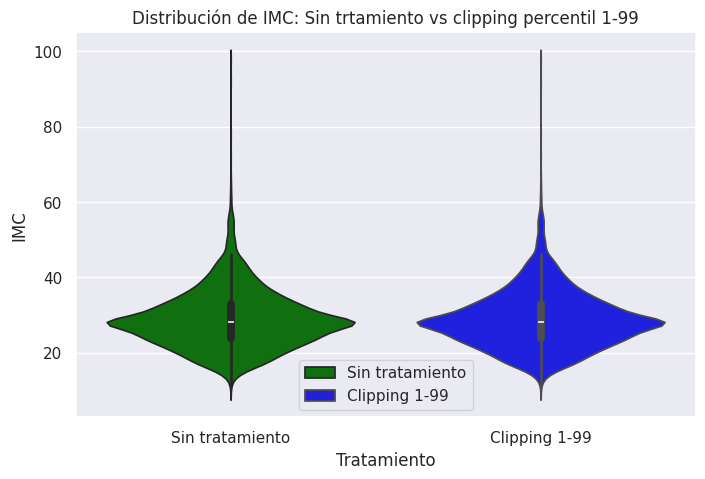

In [ ]:
# Calcular percentil de bmi
p1_BMI = df['bmi'].quantile(0.01)
p99_BMI = df['bmi'].quantile(0.99)

#Aplicar cippling/ winsorizing
cippling_bmi = df.copy()
cippling_bmi['bmi'] = cippling_bmi['bmi'].clip(p1_BMI, p99_BMI)

print('Percentil 1:', round(p1_BMI, 2))
print('Percentil 99:', round(p99_BMI, 2))
print(cippling_bmi)

# Grafico violin comparar sin tratamiento y percentil de bmi
plt.figure(figsize=(8,5))
sns.violinplot(x=['Sin tratamiento'] * len(df), y=df['bmi'], color='green', label='Sin tratamiento')
sns.violinplot(x=['Clipping 1-99'] *len(cippling_glucosa), y=cippling_glucosa['bmi'], color='blue', label='Clipping 1-99')
plt.title('Distribución de IMC: Sin trtamiento vs clipping percentil 1-99')
plt.xlabel('Tratamiento')
plt.ylabel('IMC')
plt.show()

Interpretación: Los percentiles en IMC son:

Percentil 1: (15.1)

Percentil 99: (53.4)
Esto quiere decir que, menos de un 1% de los participantes del estudio tiene un IMC menor o igual a 15.1. Es un valor muy bajo, lo cual se clasifica como bajo peso.

Por otra parte, más un 99%, tiene un IMC iguales o menores a 53.4 (obesidad tipo 3 o menos)

Es decir en rango de IMC se haya entre 15 a 53.

El gráfico de violín, indica en color verde los sin tratamiento, extendiendose hasta los 100 de IMC. No obstante, su mayor concentraciónronda entre los 20 y 40 de IMC.

Por otro lado, en color azul se muestra el violin con cippling llevando hastalos 100 de IMC, y teniendo una concentración entre los 20 y 40.

Esto revela que la mayoría tiene un IMC entre 20 a 40, pero que existen valores estremos cercanos a los 100 de IMC.

###3.Entrenar modelo baseline y comparar métricas.

In [ ]:
# Entrenar modelo baseline y comparar métricas

#Librerías para modelo lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

## Estrategia. SimpleImputer (strategy= "median")
print("--------Estrategia---------")
imputarSimple = SimpleImputer(strategy= "median")
imputarSimple_BMI = imputarSimple.fit_transform(df[['bmi']])
df['bmi'] = imputarSimple_BMI # Update the 'bmi' column in the DataFrame
#print(imputarSimple_BMI)

#Modelo lineal
# Definir variables
x = df[['bmi']]
y = df['avg_glucose_level']

#Dividir en train/test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#Modelo baseline (regresión lineal)
modelo = LinearRegression()
modelo.fit(x_train, y_train)
y_pred = modelo.predict(x_test)

#Metricas
print("--------Metricas---------")
print("Error cuadrático medio:", mean_squared_error(y_test, y_pred))
print("Coeficiente de determinación:", r2_score(y_test, y_pred))

--------Estrategia---------
--------Metricas---------
Error cuadrático medio: 1962.724126967933
Coeficiente de determinación: 0.010606286754292316


Interpretación: La regresión lineal permite evaluar la correlación entre valores continuos, como los niveles de glucosa y el IMC.
El valor del error cuadrático medio es elevado, lo cual indica que las prediciones son muy alejadas.
Por su parte, el coeficiente de determinación es de 0.04, esto indica un modelo bajo.

En conclusión, no hay sufiente evidencia de la relación lineal entre la glucosa y el IMC sea fuerte, dado que el error cuadratico medio es muy elevado y el coeficiente de determinación es muy bajo.

## EJERCICIO 8. Vectorización con NumPy vs bucles: cálculo de un score de riesgo simple

Objetivo de aprendizaje  
Optimizar cálculos con vectorización y comparar rendimiento/legibilidad.
Descripción:
Definir un score de riesgo “toy” (no clínico), como el siguiente:
• +1 si hypertension==1, +1 si heart_disease==1, +1 si age>60, +1
si avg_glucose_level>180.
• Implementar:
1. con bucle Python;
2. vectorizado con NumPy/pandas.
Nota: Un score de riesgo "toy" (o "de juguete") se refiere a un modelo de
puntuación simplificado, didáctico o experimental que no tiene validez
médica o profesional real. Se utiliza principalmente en entornos de
aprendizaje, desarrollo de software o demostraciones conceptuales para
ilustrar cómo funcionan los algoritmos de clasificación de riesgo sin la
complejidad de un sistema real


In [ ]:
#1. Bucle Python
print('Con bucle')
# Crear diccionario
diccionario = [{'hypertension':1, 'heart_disease':1, 'age':60, 'avg_glucose_level':180},
{'hypertension':0, 'heart_disease':1, 'age':50, 'avg_glucose_level':100},
{'hypertension':0, 'heart_disease':0, 'age':25, 'avg_glucose_level':100},]

# Bucle
for i in diccionario:
    i['ScoreDeRiesgo'] = 0

    if i['hypertension'] == 1:
        i['ScoreDeRiesgo'] = 1

    if i['heart_disease'] == 1:
        i['ScoreDeRiesgo'] = 1

    if i['age'] > 60:
        i['ScoreDeRiesgo'] = 1

    if i['avg_glucose_level'] > 180:
        i['ScoreDeRiesgo'] = 1

#Imprimir
for i in diccionario:
  print(i)

#*************************************************************
#*************************************************************

#2. Vectorizacion con numpy
df['ScoreDeRiesgo'] = (
    (df['hypertension']== 1).astype(int) +
    (df['heart_disease'] == 1).astype(int)+
    (df['age'] > 60).astype(int)+
    (df['avg_glucose_level'] >180).astype(int))

print('\nVectorizacion con numpy')
print(df)

#*************************************************************
#*************************************************************

#Evaluar tiempo con bucle y con vectorización
import time

#Colunmnas utilizadas
columnas = ['hypertension', 'heart_disease', 'age', 'avg_glucose_level']
X = df[columnas].dropna().to_numpy(dtype=float)

#Evaluar bucle
X_big = np.tile(X, (200, 1))
mu = X_big.mean(axis=0)
t0 = time.time()
X_loop = np.empty_like(X_big)

for i in range(X_big.shape[0]):

  for j in range(X_big.shape[1]):
    X_loop[i, j] = X_big[i, j] - mu[j]

t1 = time.time()

#Evaluar vectorización
X_vec = X_big - mu
t2 = time.time()

#Mostrar en pantalla
print("Tiempo con bucles:", t1 - t0)
print("Tiempo vectorizado:", t2 - t1)

Con bucle
{'hypertension': 1, 'heart_disease': 1, 'age': 60, 'avg_glucose_level': 180, 'ScoreDeRiesgo': 1}
{'hypertension': 0, 'heart_disease': 1, 'age': 50, 'avg_glucose_level': 100, 'ScoreDeRiesgo': 1}
{'hypertension': 0, 'heart_disease': 0, 'age': 25, 'avg_glucose_level': 100, 'ScoreDeRiesgo': 0}

Vectorizacion con numpy
         id  gender   age  hypertension  heart_disease ever_married  \
2554  72369  Female  14.0             0              0           No   
3007   3135  Female  73.0             0              0           No   
3008    563  Female  41.0             0              0          Yes   
3009  19364  Female   7.0             0              0           No   
3011  55459  Female  60.0             0              0           No   
...     ...     ...   ...           ...            ...          ...   
1166  33622    Male  62.0             1              0          Yes   
3161  51554    Male  42.0             0              0          Yes   
3162   2296    Male  78.0          

Interpretación: Con el bucle, se debe poner manualmente si la persona es hipertensa, tiene problemas cardiovasculares, la edad y el nivel de glucosa. Con sólo uno de esos datos que sobre pase la referencia: • +1 si hypertension==1, +1 si heart_disease==1, +1 si age>60, +1
si avg_glucose_level>180. El score de riesgo se dispara, esto debido a que es un bucle y en el que se deban cumplir todas las condiciones.
Un score de 0, es que no hay riesgo, un score de 1, indica que una o más condiones no están en el rango normal.

Por otra parte, desde la vectorización, se permite usar la librería numpy, lo cual facilita más el panorama. Esto debido a que permite usar funciones como astype para conocer el tipo de dato y puede detectar el dataframe con el cual se trabaja, llamar las series o variables del dataframe, y hacer una mejor búsqueda. Es mucho más funcional que un bucle, ya que permite trabajar con grandes volúmenes de datos.

## Referencias

*Choosing color palettes—Seaborn 0.13.2 documentation.* (s. f.). https://seaborn.pydata.org/tutorial/color_palettes.html?utm_source=copilot.com

*Classification of text documents using sparse features.* (s. f.). Scikit-Learn. https://scikit-learn/stable/auto_examples/text/
plot_document_classification_20newsgroups.html

Estilos en matplotlib. (2022, agosto 20). *PYTHON CHARTS | Visualización de datos con Python*. https://python-charts.com/es/matplotlib/estilos/

*Example gallery—Seaborn 0.13.2 documentation.* (s. f.). https://seaborn.pydata.org/examples/index.html

LogisticRegression. (s. f.).* Scikit-Learn*. https://scikit-learn/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

*Matplotlib—Visualization with Python *. (s. f.). https://matplotlib.org/

Naren Castellon. (2021, febrero 4). *Como cargar imagen en Python + Colab* [YOUTUBE]. https://www.youtube.com/watch?v=Lq9uLomT3pw

NumPy. (s. f.). https://numpy.org/

Suárez Benson, M. *ANÁLISIS DE DATOS ALGORITMICO*. [Material complementario]

Suárez Benson, M.* EXPLORACIÓN DE DATOS EN SALUD CON PYTHON*. [Material complementario]

*Scikit-learn: Machine learning in Python—Scikit-learn 1.8.0 documentation—Sklearn*. (s. f.). https://sklearn.org/stable/index.html

*seaborn.violinplot—Seaborn 0.13.2 documentation.* (s. f.). https://seaborn.pydata.org/generated/seaborn.violinplot.html



### Rúbrica de calificación

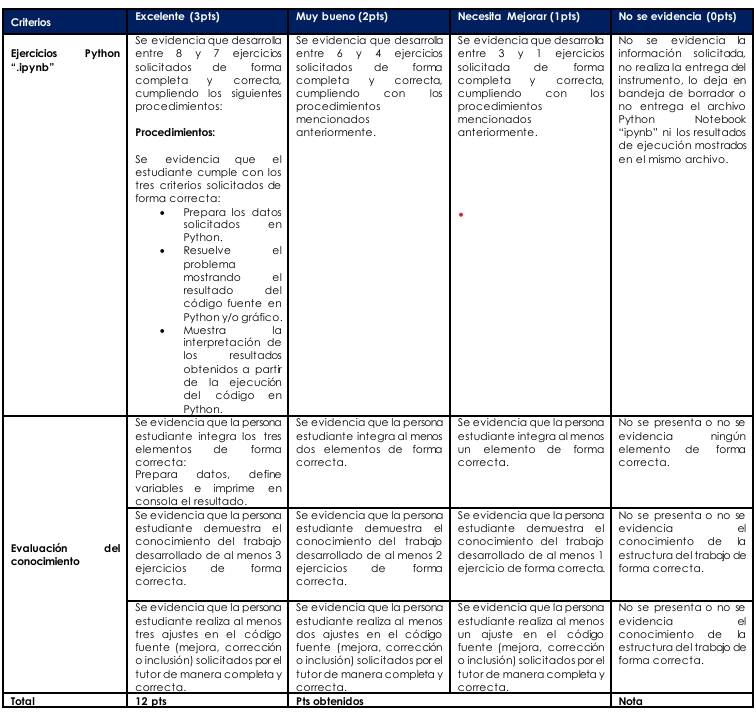

#PROYECTO 2: ANÁLISIS Y PREDICCIÓN DE EVENTOS DE PACIENTES QUE PRESENTAN LA ENFERMEDAD ICTUS

<p align="center"><p align="center"> UNIVERSIDAD ESTATAL A DISTANCIA
 <img src="https://n9.cl/clfwp" width="100" align="right">
<p align="center"> VICERRECTORÍA ACADÉMICA
<p align="center"> ESCUELA DE CIENCIAS EXACTAS Y NATURALES
<p align="center">SISTEMAS DE INFORMACIÓN EN SALUD
<p align="center"> CÁTEDRA GESTIÓN DE LA INFORMACIÓN EN SALUD


<p align="center"> PROYECTO 2: ANÁLISIS Y PREDICCIÓN DE EVENTOS DE
PACIENTES QUE PRESENTAN LA ENFERMEDAD ICTUS


Asignatura:
<p align="center">03579 - Progamación Estadística En Salud II

Estudiante:
<p align="center">Alina Elizondo Sánchez

Número de cédula de identidad:
<p align="center">0604630347

Centro Universitario:
<p align="center">Puntarenas (09)

Tutor:
<p align="center">Marvin Suárez Benson

Fecha entrega:
<p align="center">26/04/2026






# Inspección inicial del dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.spatial.distance import pdist, squareform

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


from google.colab import drive
drive.mount('/content/drive')

# Cargar dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/healthcare-dataset-stroke-data.csv')

# Limpieza ligera de nombres
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

print("Columnas:", df.columns.tolist())
print(df.head())

# Detectar variable objetivo más común
possible_targets = ['stroke', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("Variable objetivo detectada:", target_col)

Mounted at /content/drive
Columnas: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-em

In [ ]:
print("Dimensiones del dataset:", df.shape)

print("\nTipos de datos:")

print(df.dtypes)

print("\nValores faltantes por columna:")

print(df.isna().sum())


if target_col is not None:
    print("\nDistribución de la variable objetivo:")

    print(df[target_col].value_counts())

    print("\nProporciones:")

    print(df[target_col].value_counts(normalize=True))

Dimensiones del dataset: (5110, 12)

Tipos de datos:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Valores faltantes por columna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Distribución de la variable objetivo:
stroke
0    4861
1     249
Name: count, dtype: int64

Proporciones:
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


#Pregunta orientadora
¿Qué variables clínicas y demográficas parecen aportar más información
para diferenciar pacientes con mayor probabilidad de stroke, y cómo
cambian esas conclusiones cuando se analizan con herramientas
matemáticas de MAU3 frente a técnicas de modelado de MAU4?

Estas son todas las variables numéricas del CVS:


In [ ]:
# Variables numéricas
columnas_numericas = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


No obstante, el id, funciona sólo como identificador lo cual hace que no aporte mayor información sobre el riesgo de probabilidad de stroke.
Por lo que se trabajará con age, hypertension, heart_disease, avg_glucose y bmi.

##Ejercicio 1: Correlación de Pearson y Spearman
Cuantificar relaciones entre variables numéricas. Calcule las matrices de
correlación de Pearson y Spearman para las variables numéricas
seleccionadas.

In [ ]:
# Variables numéricas seleccionadas
variables_numericas = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


#Cálculo de matriz de correlación de Pearson para las variables numéricas seleccionadas
print("===================MATRIZ DE CORRELACIÓN DE PEARSON:============================")
corr_pearson = df[variables_numericas].corr(method= 'pearson')
print(corr_pearson.round(1))
print('\n')

#Cálculo de matriz de correlación de Spearman para las variables numéricas seleccionadas
print("===================MATRIZ DE CORRELACIÓN DE SPEARMAN:============================")
corr_spearman = df[variables_numericas].corr(method= 'spearman')
print(corr_spearman.round(1))
print('\n')

#Distancia de matrices
print('========DISTANCIA=======')
distancia = round(np.linalg.norm(corr_pearson - corr_spearman),2)
print('Distancia entre ambas matrices:', (distancia))

===================MATRIZ DE CORRELACIÓN DE PEARSON:============================
                   age  hypertension  heart_disease  avg_glucose_level  bmi
age                1.0           0.3            0.3                0.2  0.3
hypertension       0.3           1.0            0.1                0.2  0.2
heart_disease      0.3           0.1            1.0                0.2  0.0
avg_glucose_level  0.2           0.2            0.2                1.0  0.2
bmi                0.3           0.2            0.0                0.2  1.0


===================MATRIZ DE CORRELACIÓN DE SPEARMAN:============================
                   age  hypertension  heart_disease  avg_glucose_level  bmi
age                1.0           0.3            0.3                0.1  0.4
hypertension       0.3           1.0            0.1                0.1  0.2
heart_disease      0.3           0.1            1.0                0.1  0.1
avg_glucose_level  0.1           0.1            0.1                1.0  0.1

**Interpretación**

En este ejercicio se obtienen tanto la correlación de Pearson como la de Spearman, con el objetivo de medir la asociación entre variables.

La correlación de Pearson mide la asociación lineal, por su parte la de Spearman mide la asociación monótoma.

Se percibe que la variable que tiene mayor diferenciación de un tipo de correlación a la otra es el nivel promedio de glucosa.

**Pearson:** Se nota una correlación positiva de todas las variables, la fuerza de correlación entre la variables es baja, ya que se sitúa entre valores absolutos entre 0.1 a 0.3.

**Spearman:** Se nota una correlación positiva de todas las variables, la fuerza de correlación entre la variables está entre baja a moderada ( 0.3 a 0.5).

Midiendo la distancia se puede observar que es muy poca la diferencia entre ambas correlaciones.


##  Ejercicio 2: Autovalores y autovectores de la matriz de covarianza
Calcule la matriz de covarianza de las variables numéricas y obtenga
sus autovalores y autovectores.

In [ ]:
#Estandarizar los datos con StandarScaler de scikit-learn
print("===================ESTANDARIZACIÓN DE DATOS:============================")
from sklearn.preprocessing import StandardScaler
escala = StandardScaler()
df[variables_numericas] = escala.fit_transform(df[variables_numericas])

#Calcular matriz de covarianza de las variables numericas
print("===================MATRIZ DE COVARIANZA:============================")
matriz_covarianza = df[variables_numericas].cov()
print(matriz_covarianza.round(2))

#Tabla de matriz de covarianza
columnas_covarianza = variables_numericas
Xcov = df[columnas_covarianza].dropna().to_numpy(dtype=float)
cov_matrix = np.cov(Xcov, rowvar=False)
cov_df = pd.DataFrame(cov_matrix, index=columnas_covarianza, columns=columnas_covarianza)
display(cov_df.round(2))
print('\n')

#Calcular los autovectores y autovectores
autovalores, autovectores = np.linalg.eig(matriz_covarianza)
print('=================AUTOVALORES:=======================\n', autovalores)
print('\n')
print('=================AUTOVECTORES:=======================\n', autovectores)

===================ESTANDARIZACIÓN DE DATOS:============================
===================MATRIZ DE COVARIANZA:============================
                    age  hypertension  heart_disease  avg_glucose_level   bmi
age                1.00          0.28           0.26               0.24  0.33
hypertension       0.28          1.00           0.11               0.17  0.16
heart_disease      0.26          0.11           1.00               0.16  0.04
avg_glucose_level  0.24          0.17           0.16               1.00  0.17
bmi                0.33          0.16           0.04               0.17  1.00


,age,hypertension,heart_disease,avg_glucose_level,bmi
age,1.00,0.27,0.25,0.23,0.33
hypertension,0.27,0.95,0.11,0.17,0.16
heart_disease,0.25,0.11,0.92,0.15,0.04
avg_glucose_level,0.23,0.17,0.15,0.96,0.17
bmi,0.33,0.16,0.04,0.17,1.00




=================AUTOVALORES:=======================
 [1.80112333 0.58011316 0.9668426  0.81928915 0.83361844]


=================AUTOVECTORES:=======================
 [[-0.56988194 -0.76024837 -0.02121593  0.28628907  0.12184187]
 [-0.42574549  0.21590941 -0.15303615  0.0811608  -0.86146199]
 [-0.35300914  0.37688773  0.79039555  0.29037966  0.1558676 ]
 [-0.4266688  -0.00184553  0.11665123 -0.89059225  0.10577462]
 [-0.43279744  0.48307119 -0.58120322  0.18432742  0.45558184]]


**Interpretación**

Primeramente se estandarizan los datos y seguidamente se crea la tabla de la matriz de covarianza.
En esta tabla se puede visualizar, que todas las covarianzas son positivas. Es decir, las variables se mueven en las misma dirección. Por ejemplo, a mayor edad tiende a aumentar la presión arterial(0.28).


Finalmente, se calculan los autovalores y autovectores, los cuáles se calculan a partir de la matrix de covarianza y posibilitan estudiar las direcciones en la variaribilidad de los datos.
Aquí tenemos 5 autovalores, el primero(1.80112333) es el que tiene más expansión, es decir, es donde hay más variabilidad, en los demás los datos están muy agrupados.
Por su parte, los autovectores, están cosntituidos por una matriz 5x5.


## Ejercicio 3. PCA: varianza explicada y número de componentes.
Objetivo
Reducir dimensionalidad sin perder demasiada información.
Estandarice las variables numéricas y aplique PCA. Reporte:
• varianza explicada por componente,
• varianza acumulada,
• número de componentes necesarias para superar 80%.

============Proporción de varianza explicada por cada componente principal:========== 
Componente (PC1): 0.360 (36.0%))
Componente (PC2): 0.116 (11.6%))
Componente (PC3): 0.193 (19.3%))
Componente (PC4): 0.164 (16.4%))
Componente (PC5): 0.167 (16.7%))

=========Varianza acumulada:==========
Componente (PC1): 0.360 (16.7%)
Componente (PC2): 0.476 (16.7%)
Componente (PC3): 0.669 (16.7%)
Componente (PC4): 0.833 (16.7%)
Componente (PC5): 1.000 (16.7%)

Número de componentes para superar el 80% de varianza explicada: 4


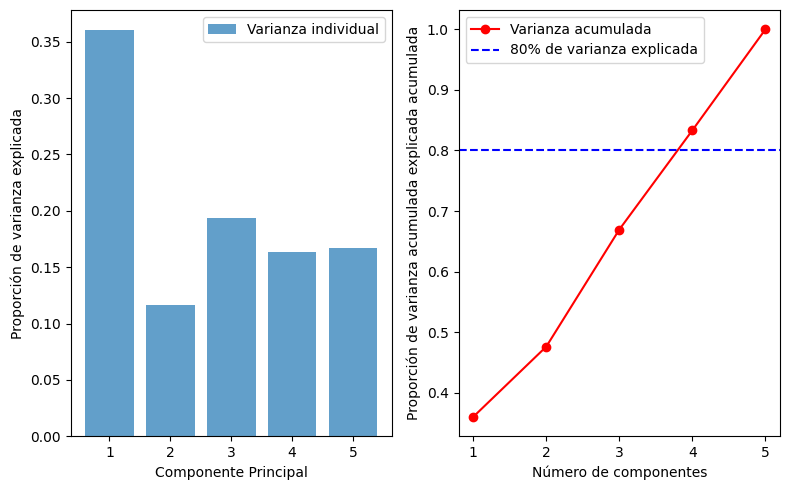

In [ ]:
#Varianza explicada por componente
varianza_explicada_por_componente = autovalores / np.sum(autovalores)
print('============Proporción de varianza explicada por cada componente principal:========== ')
for i, ratio in enumerate(varianza_explicada_por_componente):
  print(f"Componente (PC{i+1}): {ratio:.3f} ({ratio*100:.1f}%))")

#Varianza acumulada
varianza_acumulada = np.cumsum(varianza_explicada_por_componente)
print('\n=========Varianza acumulada:==========')
for i, cum_ratio in enumerate(varianza_acumulada):
  print(f"Componente (PC{i+1}): {cum_ratio:.3f} ({ratio*100:.1f}%)")

# Número de componentes necesarios para superar 80%
num_componentes_80_por_ciento = np.where(varianza_acumulada >= 0.8)[0][0] + 1
print(f'\nNúmero de componentes para superar el 80% de varianza explicada: {num_componentes_80_por_ciento}')

#Visualización de la varianza explicada
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.bar(range(1, len(varianza_explicada_por_componente )+1), varianza_explicada_por_componente, alpha=0.7, label = 'Varianza individual')
plt.xlabel('Componente Principal')
plt.ylabel('Proporción de varianza explicada')
plt.xticks(range(1, len(varianza_explicada_por_componente)+1))
plt.legend()

#Visualización de la varianza acumulada
plt.subplot(1,2,2)
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 'ro-', label='Varianza acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Proporción de varianza acumulada explicada acumulada')
plt.xticks(range(1, len(varianza_acumulada)+1))
plt.axhline(y=0.8, color='blue', linestyle='--', label='80% de varianza explicada')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación**
Este análisis de componentes principales (PCA), se obtiene el porcentaje de varianza de cada componente, donde a partir del componente 4, se obtiene el 80% de la varianza. En otras palabras, con 4 componentes se puede generar un análisis equilibrado sin perder información importante y reduciendo la dimensionalidad.

Mediante el gráfico de barras se puede visualizar, la varianza de cada componente, por ejemplo, el PC1, es el que mayor varianza posee, lo cual es de gran ayuda para completar el PCA, en el cuarto componente.

Por otro lado, el gráfico lineal, permite ver que cada punto en rojo, muestra los PCA, y la línea horizontal azul permite conocer cuando se cumple el 80% de la varianza.

## Ejercicio 4. PCA: varianza explicada y número de componentes.
Objetivo
Explorar si los casos con stroke presentan patrones visuales diferenciales.
Grafique los datos en las dos primeras componentes principales y coloree
según stroke.

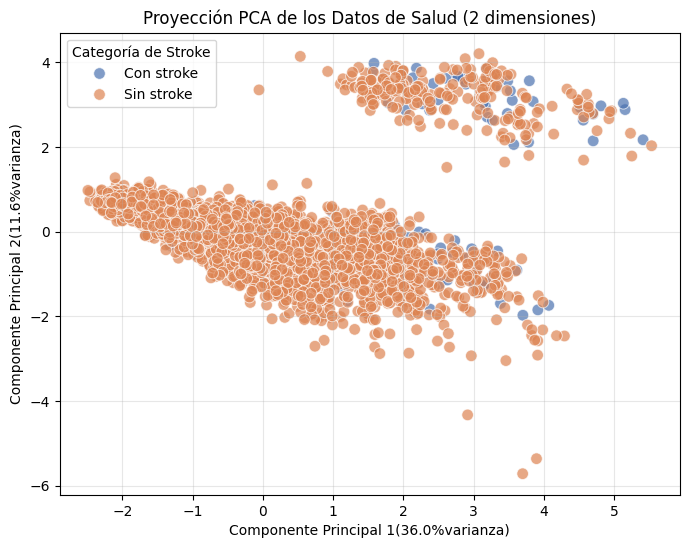

In [ ]:
#Reducir a 2 componentes y visualizar
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

#Variables numéricas
variables_numericas = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

# Imputar los valores faltantes en 'bmi' antes de aplicar PCA
imputer = SimpleImputer(strategy='median')
df_imputed = df[variables_numericas].copy()
df_imputed['bmi'] = imputer.fit_transform(df_imputed[['bmi']])

x = df_imputed

#Reducción a dos componentes
pca = PCA(n_components=2)
componentes_principales=  pca.fit_transform(x)

#Creación de un dataframe con los componentes para facilitar el plotting
df_pca = pd.DataFrame(data= componentes_principales,columns= ['PCA1','PCA2'])

#Colorear según stroke
df_pca['Categoría_Stroke'] = df['stroke'].map({0: 'Sin stroke', 1: 'Con stroke'})


#Gráfico
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x= 'PCA1', y= 'PCA2', hue= 'Categoría_Stroke', palette= 'deep', alpha= 0.7, s=70)
plt.xlabel(f'Componente Principal 1({varianza_explicada_por_componente[0]:.1%}varianza)')
plt.ylabel(f'Componente Principal 2({varianza_explicada_por_componente[1]:.1%}varianza)')
plt.title('Proyección PCA de los Datos de Salud (2 dimensiones)')
plt.legend(title='Categoría de Stroke')
plt.grid(True, alpha= 0.3)
plt.show()

**Interpretación**
Este gráfico de dispersión muestra un punto por cada paciente. En el eje x, se encuentra el componente principal con una varianza de 36%, mientras que, en el eje y se encuentra el componente principal con un 11.6%.

Los puntos de color azul muestran los pacientes con stroke y los puntos de color naranja los pacientes sin stroke. Del cual se visualiza que predominan los pacientes sin stroke, en los dos sectores donde se agrupan los datos. En el grupo más grande se aprecia mayor concentración de los datos, mientras el grupo pequeño sugiere mayor variabilidad.

## Ejercicio 5. Matriz de distancias entre pacientes
Objetivo
Comparar observaciones clínicas a partir de métricas de distancia.
Seleccione 15 pacientes y calcule:
• matriz de distancia euclidiana,
• matriz de distancia Manhattan.
Identifique el paciente más cercano al paciente 0.

In [ ]:
from scipy.spatial.distance import pdist, squareform
from sklearn.impute import SimpleImputer

# Variablrs nunéricas
variables_numericas = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

# Imputar bmi
imputer = SimpleImputer(strategy='median')
df['bmi'] = imputer.fit_transform(df[['bmi']])

#Seleccionar 15 pacientes
muestra_15_pacientes = df[variables_numericas].iloc[:15, :]

print ('MATRIZ DE DISTANCIA EUCLIDIANA')
distancia_euclidiana = squareform(pdist(muestra_15_pacientes, metric='euclidean'))
print(distancia_euclidiana.round(2))

print ('\nMATRIZ DE DISTANCIA MANHATTAN')
distancia_manhattan = squareform(pdist(muestra_15_pacientes, metric='cityblock'))
print(distancia_manhattan.round(2))

# Identificar el paciente más cercano al paciente 0
# Para distancia Euclidiana
print('\nPara la distancia Euclidiana el paciente más cercano al paciente 0 (Euclidiana) es el paciente', np.argmin(distancia_euclidiana[0, 1:]) + 1, 1, 'con distancia de', distancia_euclidiana [0,1:].min().round(2))

# Para distancia Manhattan
print('Para la distancia Manhattan el paciente más cercano al paciente 0 (Manhattan) es el paciente', np.argmin(distancia_manhattan[0, 1:]) + 1, 'con distancia de', distancia_manhattan [0,1:].min().round(2))

MATRIZ DE DISTANCIA EUCLIDIANA
[[0.   4.6  2.82 4.68 5.94 4.67 5.01 5.61 5.68 6.03 6.54 2.41 5.37 1.2
  1.24]
 [4.6  0.   5.01 1.18 3.56 0.96 6.31 2.5  2.79 3.3  4.41 4.9  2.18 4.5
  4.5 ]
 [2.82 5.01 0.   4.86 5.86 4.79 3.53 4.63 4.6  4.67 5.6  1.05 4.62 2.58
  2.45]
 [4.68 1.18 4.86 0.   3.86 1.61 6.16 2.42 2.29 3.09 4.21 4.6  1.74 4.8
  4.78]
 [5.94 3.56 5.86 3.86 0.   3.44 5.01 3.83 4.14 4.23 2.19 5.97 3.89 5.68
  5.66]
 [4.67 0.96 4.79 1.61 3.44 0.   6.14 2.24 2.62 2.89 4.1  4.84 2.17 4.49
  4.47]
 [5.01 6.31 3.53 6.16 5.01 6.14 0.   5.62 5.6  5.59 4.45 3.79 5.68 4.73
  4.64]
 [5.61 2.5  4.63 2.42 3.83 2.24 5.62 0.   0.9  0.9  3.54 4.82 0.9  5.28
  5.22]
 [5.68 2.79 4.6  2.29 4.14 2.62 5.6  0.9  0.   1.05 3.52 4.67 0.67 5.51
  5.44]
 [6.03 3.3  4.67 3.09 4.23 2.89 5.59 0.9  1.05 0.   3.48 4.96 1.52 5.7
  5.62]
 [6.54 4.41 5.6  4.21 2.19 4.1  4.45 3.54 3.52 3.48 0.   5.77 3.63 6.36
  6.3 ]
 [2.41 4.9  1.05 4.6  5.97 4.84 3.79 4.82 4.67 4.96 5.77 0.   4.61 2.57
  2.47]
 [5.37 2.18 4

### 5.1 Mapa de calor Euclidiano

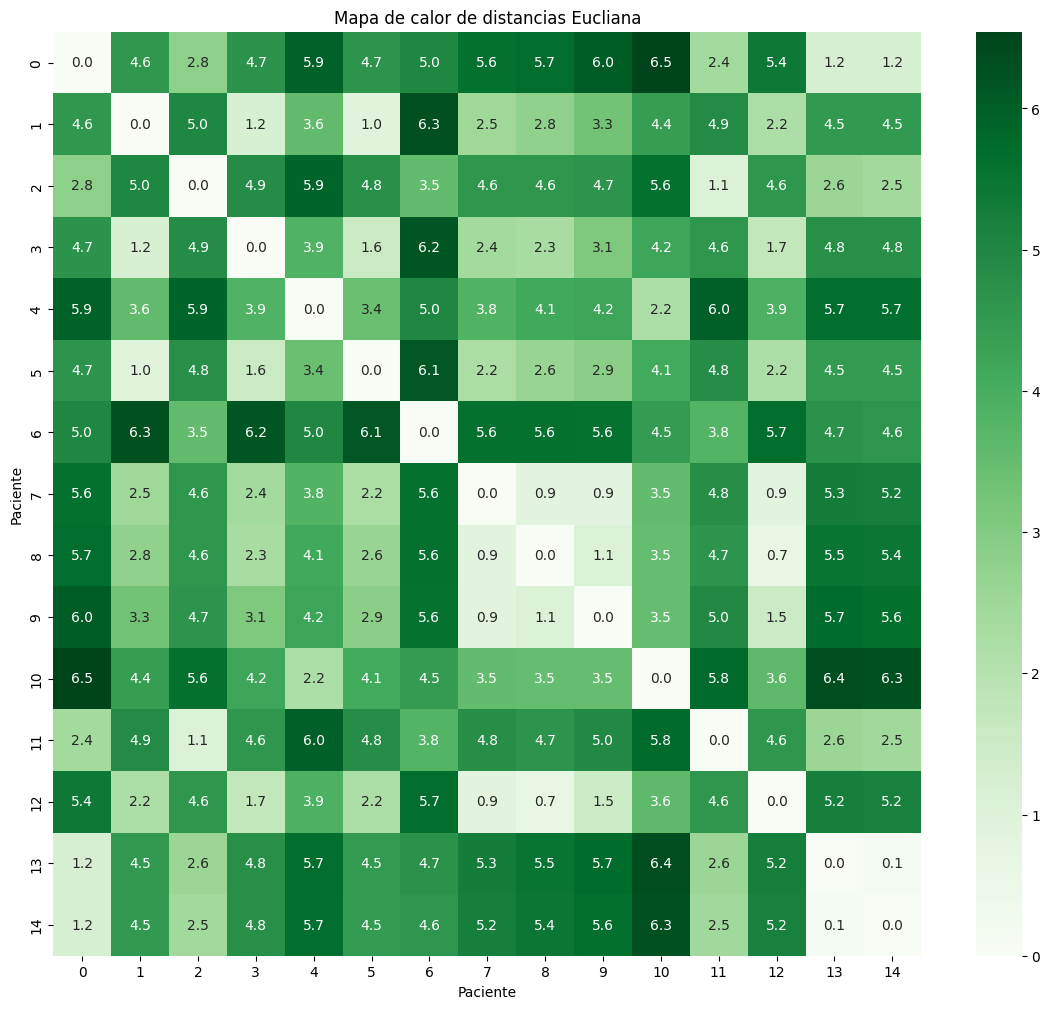

In [ ]:
#Representación Eucliana

plt.figure(figsize=(14, 12))
sns.heatmap(distancia_euclidiana, annot= True, fmt= '.1f', cmap="Greens")
plt.title('Mapa de calor de distancias Eucliana')
plt.xlabel('Paciente')
plt.ylabel('Paciente')
plt.show()

**Interpretación**
En este gráfico, se puede notar que pasa una línea diagonal, constituida por ceros.
Asimismo, funciona para conocer cual es la distancia entre variables. Los casos de color verde claro, se asocian con pacientes con menor números de características en común. Mientras, los que tienen un verde oscuro, se trata de pacientes con características similares.
Por ejemplo, en la primera fila 0 y la columna 9. Es decir el paciente 0 y el 9, tienen mucho en común, por ello, el resultado o distancia se posiciona en 170.9
Mientras que el paciente 13 y el 14, se encuentran menos relacionados, con un 5.8 de distancia Euclediana.

### 5.2. Mapa de calor Manhathan

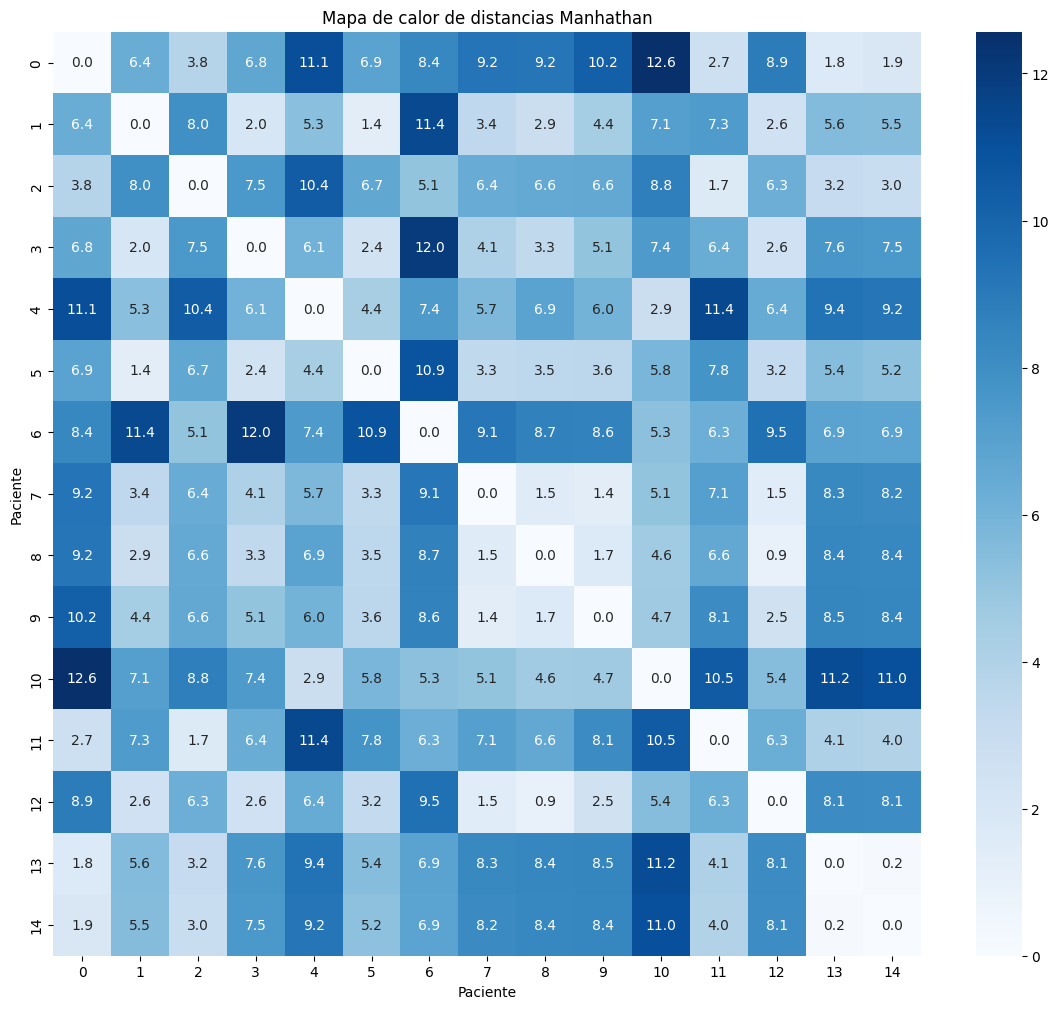

In [ ]:
#Representación Manhatthan
plt.figure(figsize=(14, 12))
sns.heatmap(distancia_manhattan, annot= True, fmt= '.1f',cmap="Blues")
plt.title('Mapa de calor de distancias Manhathan')
plt.xlabel('Paciente')
plt.ylabel('Paciente')
plt.show()

**Interpretación**

El este gráfico de calor representando la distancia Manhathan, se puede visualizar una mayor variabilidad de los datos en comparación con la eucliadiana.

Los casos de color azul claro, se asocian con pacientes con menor números de características en común. Mientras, los que tienen un azul oscuro, se trata de pacientes con características similares.

El paciente 0 y el 9, tienen mucho en común. Por ello el todo es de color azul oscuro con un 194.5.

Mientras el paciente 12 y el 5, presentan menores características en común, con una distancia de 31.5.


## Ejercicio 6. Matriz de distancias entre pacientes
Objetivo:
Estudiar la forma de variables clínicas continuas.
Analice la distribución de avg_glucose_level:
• histograma,
• prueba de normalidad de Shapiro sobre una muestra,
• ajuste normal y gamma,
• comparación básica mediante estadístico KS.


### 6.1.Histograma

count    5110.00
mean        0.00
std         1.00
min        -1.13
25%        -0.64
50%        -0.31
75%         0.18
max         3.66
Name: avg_glucose_level, dtype: float64


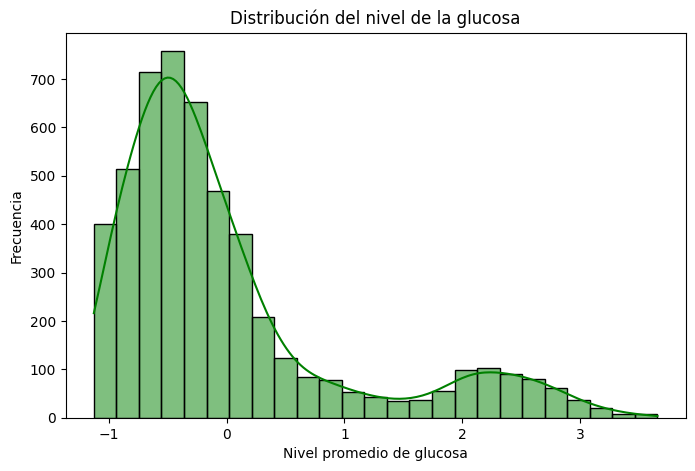

In [ ]:
#Limpieza de datos
if 'avg_glucose_level' in df.columns:
    x = df['avg_glucose_level'].dropna()
#Estadísticas descriptivas
    print(x.describe().round(2))

#Histograma
plt.figure(figsize=(8,5))
sns.histplot(x, kde=True, bins= 25, color= 'green', edgecolor= 'black')
plt.title('Distribución del nivel de la glucosa')
plt.xlabel('Nivel promedio de glucosa')
plt.ylabel('Frecuencia')
plt.show()

**Interpretación**

Se realizaron 5110 tomas de colesterol.

El promedio de colesterol es de 106.15

La desviación estándar es de 45.28

La glucosa mínima es de 55.12 y la máxima es de 271.74.

Un 25% de las medidas de glucosa es de 77.24, un 50% o la mitad tiene una glucosa de 91.88 y un 75% es 114.09.

Del gráfico, se puede visualiza que:

Se tiene asimetría positiva (sesgada a la derecha), es decir la mayoría tiene el promedio de la glucosa en 106.16, pero existen valores extremadamente altos que "jalan" hacia la derecha.

La desviación estándar (45.28) posee una dispersión moderada alrededor del promedio (106.15), coherente con la forma obervada en el gráfico

### 6.2.Prueba de normalidad de Shapiro sobre una muestra

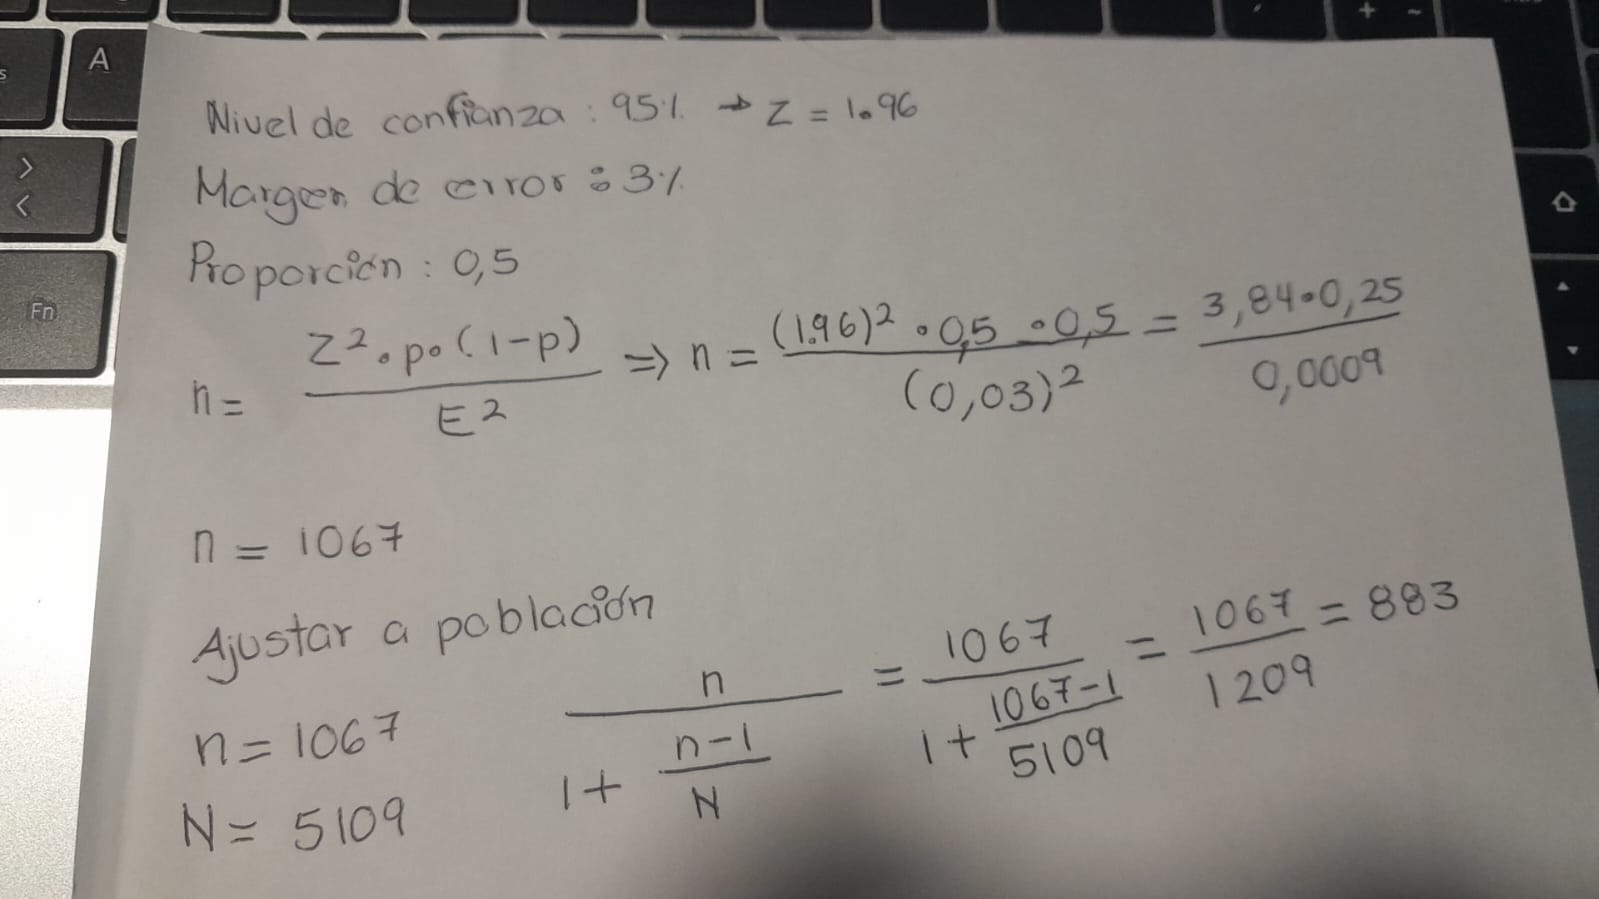


Para una población de 5109 pacientes, con un 95 % de confianza y un margen de error de 3%, la muestra es de 883 pacientes.

In [ ]:
from scipy import stats

#Toda la población
#shapiro_stat, shapiro_p = stats.shapiro(df['avg_glucose_level'])

#Muestra
muestra = df['avg_glucose_level'].sample(n=883, random_state= 50)
shapiro_stat, shapiro_p = stats.shapiro(muestra)

print(f'Prueba de Shapiro-Wilk: Estadístico: {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}')
if shapiro_p > 0.05:
  print('No se rechaza la hipotesis de normalidad (los datos podrían ser normales)')
else:
  print('Se rechaza la hipotésis de normalidad (los datos no siguen una distribución normal)')

**Interpretación:**
Con esta prueba Shapiro- Wilk, se tiene que el p-value es menor que 0.05, por lo que se rechaza la hipótesis. Al no seguir los datos una distribución normal se toman las medidas necesarias para utilizar otras pruebas estadísticas.

### 6.3. Ajuste normal y gamma

In [ ]:
#Importación
from scipy import stats
from scipy.spatial.distance import squareform, pdist

#Variable nivel promedio de glucosa
variable = 'avg_glucose_level' if 'avg_glucose_level' in df.columns else variables_numericas[0]
x = df[variable].dropna().to_numpy(dtype=float)

#Ajuste normal
mu, sigma = stats.norm.fit(x)

#Ajuste gamma
valores_positivos = x[x > 0]
shape, loc, scale = stats.gamma.fit(valores_positivos, floc=0)

### Comparación básica mediante estadístico KS.

=============NORMAL=================:
mu: 0.0
sigma 1.0
pvalue: 0.0

===============GAMMA:============
forma: 0.8357
Escala: 1.3577
pvalue: 0.0


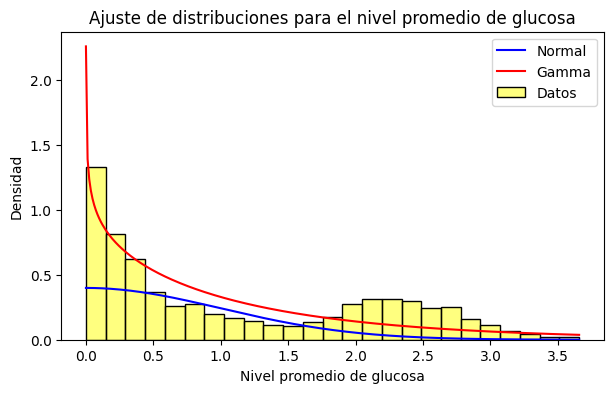

In [ ]:
#Compración de normal y gamma mediante estadístico KS
ks_normal = stats.kstest(x, "norm", args=(mu, sigma))
ks_gamma = stats.kstest(valores_positivos, "gamma", args=(shape, loc, scale))

#Mostrar
print('=============NORMAL=================:')
print('mu:',  round(mu, 4))
print('sigma', round(sigma, 4))
print('pvalue:', round(ks_normal.pvalue, 4))
print('\n===============GAMMA:============' )
print('forma:', round(shape, 4))
print('Escala:', round(scale, 4))
print('pvalue:', round(ks_gamma.pvalue, 4))

#Grafico
plt.figure(figsize=(7,4))
sns.histplot(valores_positivos, stat='density', bins=25, color= 'yellow',alpha=0.5, label='Datos')
xx = np.linspace(valores_positivos.min(), valores_positivos.max(), 300)
plt.plot(xx, stats.norm.pdf(xx, mu, sigma), color = 'blue', label='Normal')
plt.plot(xx, stats.gamma.pdf(xx, shape, loc=loc, scale=scale), color= 'red', label='Gamma')
plt.title(f'Ajuste de distribuciones para el nivel promedio de glucosa')
plt.xlabel('Nivel promedio de glucosa')
plt.ylabel('Densidad')
plt.legend()
plt.show()

**Interpretación**

El p-value del ajuste normal es de 0.0 < 0.05. Es decir, se rechaza  la hipótesis nula con relación a una distribución normal. Por otra parte, la distribución gamma, posee un p-value de 0.0 < 0.05, lo cual indica que se rechaza la hipotesis
En otras palabras, rechaza ambos tipos de distribución (normal y gamma), ya que no se ajustan al tipo de distribución que poseen estos datos. Tal como se indico, en el ejercicio anterior de Shapiro, los datos no siguen una distribución normal.

## Ejercicio 7. Preparación formal de datos con Pipeline y ColumnTransformer
Objetivo
Preparar el dataset para entrenamiento para evitar perdida o fuga de
información.
Considere lo siguiente:
• separe variables predictoras y objetivo,
• divida en entrenamiento y prueba con estratificación,
• impute faltantes,
• escale variables numéricas,
• codifique variables categóricas.
Entregable
Muestre la forma de la matriz transformada.

In [ ]:
#Importaciones
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#• Separar variables predictoras y objetivo
if target_col is None:
    print('No se detectó la variable objetivo. Revisa el nombre de la columna en tu dataset.')
else:

    y = df[target_col].astype(int)
    X_df = df.drop(columns=[target_col])

    variables_numericas = X_df.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X_df.select_dtypes(exclude=np.number).columns.tolist()

#• División en entrenamiento y prueba con estratificación
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.25, random_state=42, stratify=y
    )

#• Preprocesamiento (imputación de faltantes y escalamiento de variables numéricas)
    preprocesamiento = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), variables_numericas),
        ("cat", Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
          # • Codificación variables categóricas.
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), variables_categoricas)
    ], remainder='drop')

    X_train_transformed = preprocesamiento.fit_transform(X_train)
    X_test_transformed = preprocesamiento.transform(X_test)

## Entregable. Muestre la forma de la matriz transformada.
#Mostrar datos de entrenamiento y test
    print('Entrenamiento:', X_train.shape)
    print('Prueba:', X_test.shape)


Entrenamiento: (3832, 11)
Prueba: (1278, 11)


**Interpretación:**
En el entrenamiento se obtiene una dimensión de 3832 registros y 11 columnas predictoras.
Los datos de prueba generados evalúan 1278 registros de prueba y 13 columnas predictoras que permiten hacer la prueba para luego poder generalizar los resultados del modelo.
Dicho de otra forma, este es un proceso que ayuda a evaluar la capacidad de generalización del moedelo, permitiendo que el algoritmo aprenda patrones a partir de los datos suministrados.

## Ejercicio 8. Modelo base: regresión logística y métricas de clasificación
Objetivo
Entrenar un primer clasificador supervisado.
Construya un pipeline con el preprocesamiento y una regresión logística.
Evalúe:
• accuracy,
• precision,
• recall,
• F1,
• AUC,
Grafique:
• matriz de confusión,
• curva ROC.

In [ ]:
#Importaciones
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#Definición de pipeline
if target_col is not None:
    pipe = Pipeline([
        ('prep', preprocesamiento),
        ('model', LogisticRegression(max_iter=500))
    ])

#Entrenamiento
    pipe.fit(X_train, y_train)

#Prediciciones y probabilidades
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

#Evaluación
    print('Accuracy (predicciones correctas):', round(accuracy_score(y_test, y_pred), 2))
    print('Precision (precisión):', round(precision_score(y_test, y_pred), 2))
    print('Recall (sensibilidad):', round(recall_score(y_test, y_pred), 2))
    print('F1 (media entre precisión y sensibilidad):', round(f1_score(y_test, y_pred), 2))
    print('AUC (área bajo la curva ROC):', round(roc_auc_score(y_test, y_prob), 2))

Accuracy (predicciones correctas): 0.95
Precision (precisión): 1.0
Recall (sensibilidad): 0.03
F1 (media entre precisión y sensibilidad): 0.06
AUC (área bajo la curva ROC): 0.84


**Interpretación**
De seguida se muestran las métricas iniciales de clasificación:

Se indica que un 95% de las prediciones (positivos y negativos)son aparentemente correctas. Sin embargos, hay muchos sin Ictus y pocos con ictus.

La precisión de 100%, indica la confiabliidad de afirmar cuando un caso es positivo. Pero, no predice casi personas con Ictus

Una sensiblidad de 3%, indica los casos positivos verdaderos. Pero, podría haber un problema con los demás casos positivos. Sólo detecta que el 3% tiene Ictus.

Además, la media entre la precisión y la sensibilidad es de 6%, lo cual sugiere un bajo nivel para identificar positivos.

Y el área bajo la curva ROC  es de 84%, lo cual indica que resume bastante bien la discriminación de un clasificador, pero deja muchos positivos por fuera.
Por lo cual, se concluye que el modelo no esta prediciendo bien los casos positivos. Por lo que, una opción sería bajar el umbral.

## Ejercicio 9. Comparación de modelos con validación cruzada
Objetivo
Comparar algoritmos supervisados bajo una evaluación más robusta.
Compare, mediante validación cruzada estratificada y AUC:
• regresión logística,
• random forest.

LogisticRegression (Regresión logística) AUC media: 0.8367
DecisionTree (árbol de decisión) AUC media: 0.5677
RandomForest (bosque aleatorio) AUC media: 0.7951
Mejores parámetros: {'modelo__max_depth': 5, 'modelo__n_estimators': 200}
AUC en test: 0.8384


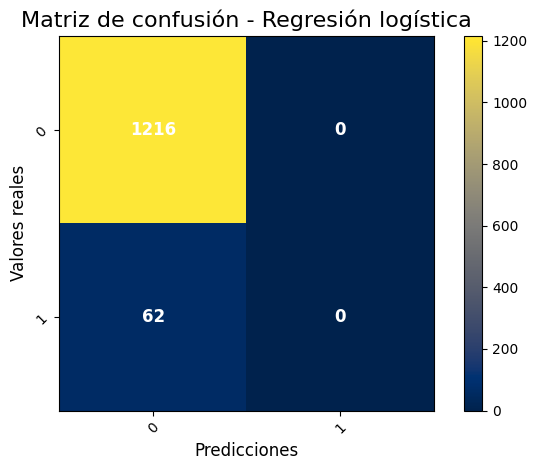

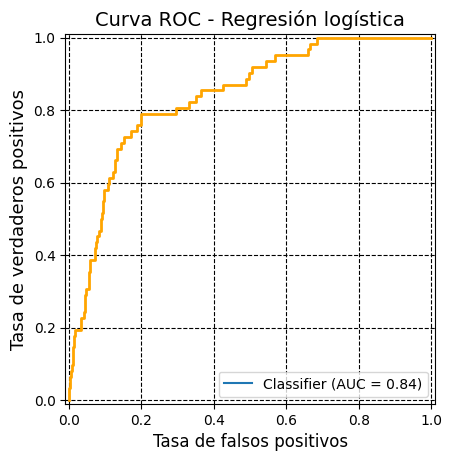

In [ ]:
#Importaciones
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

#Definición de modelos
if target_col is not None:
    models = {
        'LogisticRegression (Regresión logística)': Pipeline(
            [("prep", preprocesamiento), ("model", LogisticRegression(max_iter=5000))]
        ),
        'DecisionTree (árbol de decisión)': Pipeline(
            [("prep", preprocesamiento), ("model", DecisionTreeClassifier(random_state=42))]
        ),
        'RandomForest (bosque aleatorio)': Pipeline(
            [("prep", preprocesamiento), ("model", RandomForestClassifier(random_state=42))]
        ),
    }

#Validación cruzada
    validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for nombre, modelo in models.items():
        puntos_auc = cross_val_score(modelo, X_df, y, cv=validacion_cruzada, scoring="roc_auc")
        print(nombre, 'AUC media:', round(puntos_auc.mean(), 4))

    rf_pipe = Pipeline([('Preparacion', preprocesamiento), ('modelo', RandomForestClassifier(random_state=42))])

# Ajuste de hiperparámetros
    param_grid = {
        "modelo__n_estimators": [100, 200],
        "modelo__max_depth": [3, 5, None],
    }

    busqueda= GridSearchCV(rf_pipe, param_grid=param_grid, cv=validacion_cruzada, scoring="roc_auc", n_jobs=-1)

    busqueda.fit(X_train, y_train)

#Resultados del mejor parámetro
    print("Mejores parámetros:", busqueda.best_params_)

    best_model = busqueda.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    print("AUC en test:", round(roc_auc_score(y_test, y_prob), 4))

#Visualización
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap= 'cividis')
    plt.title('Matriz de confusión - Regresión logística', fontsize= 16)
    plt.xlabel('Predicciones',fontsize= 12)
    plt.ylabel('Valores reales', fontsize= 12)
    for text in disp.text_.ravel():
        text.set_color('white')
        text.set_fontsize(12)
        text.set_fontweight('bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    print('\n')

    roc_disp = RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title('Curva ROC - Regresión logística', fontsize= 14)
    plt.xlabel('Tasa de falsos positivos', fontsize= 12)
    plt.ylabel('Tasa de verdaderos positivos', fontsize= 13)
    roc_disp.line_.set_color('orange')
    roc_disp.line_.set_linewidth(2)
    plt.grid(True, linestyle= 'dashed', color= 'black')
    plt.show()

**Interpretación:**
La regresión logística AUC media con un 0.8367 discrimina bastante bien entre las clases.

Un árbol de decisión de AUC media de 0.5677 es bajo, por lo que se pierde considerablemente la capacidad para distinguir entre clases.

El bosque aleatorio AUC media de 0.7951, es regular.

De acuerdo con los mejores parámetros, el modelo de mayor profundidad es 5, 'con un número estimador de 200.

El AUC del test es de 0.8384, lo cual suguiere que a partir de ese nivel los modelos son buenos. El único modelo que cumple con esos estándares es el de regresión logística. Este es el que mayor capacidad tiene de reducir el sobreajuste y distinguir entre clases.

En base a esta matriz de confusión se obtiene:

Verdaderos negativos: 1216
Personas sin Ictus clasificadas correctamente como sin Ictus.

Falsos positivos: 0
Personas sin Ictus clasificadas como con Ictus.

Falsos negativos: 62
Personas con Ictus, clasificadas como sin Ictus.

Verdaderos negativos: 0
Personas con Ictus, correctamente diagnosticadas como con Ictus

Existe un gran problema el modelo no detecta personas con Ictus.

En el gráfico área bajo la curva se visualizan los modelos. La regresión lineal se ve que esta por encima de 0.8, al principio se mantiene de forma ascendente e irregular y al final se establecese una línea constante.
El árbol de decisión se ubica entre 0.4 y 0.6, es ascendente e irregular. Por último, el bosque aleatorio, esta ubicado en 0.8, se mantiene con una línea constante.

## Ejercicio 10. Clustering con K-means y visualización con PCA
Objetivo
Explorar estructura no supervisada en los datos.
Use solo variables numéricas:
• escale los datos,
• evalúe k=2,3,4,5 con silhouette,
• elija un valor de k,
• entrene K-means,
• visualice los clusters en 2 componentes principales,
• compare clusters con la variable stroke.

In [ ]:
#Importaciones
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# Definir la variable numérica
variables_numericas = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

#Extracción de las variables para la creación de una copia
cluster = df[variables_numericas].copy()

# Imputar el clustering
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(cluster)

# Escalamiento de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

#PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

#Visualización de Kmeans y clusteres
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

#Silhouette
silhouette = silhouette_score(X_scaled, clusters)
print("Silhouette:", round(silhouette, 2))

Silhouette: 0.45


**Interpretación:**
En este ejercicio ejecuta otra métrica de evaluación del modelo, denominada coeficiente de silueta (Silhouette), que tiene como principal función evaluar la media entre clústeres.
Un coeficiente de 0.45, se puede considerar como una separación moderada entre clusteres. No obstante se puede mejorar.

# Preguntas finales

1.	¿Qué hallazgos fueron más claros desde un punto matemático
El primer hallazgo más claro fue la correlación de Pearson y Spearman, porque ambas medir la asociación entre variables y su diferencia fue de 0,21, lo cual permite obtener que no hay una diferencia significante. Ambos ayudan a conocer más la asociación de las variables que se trabajaran.
El segundo hallazgo fue la varianza explicada, ya que la proporción de cada variable coincide con los gráficos, los cuales también desde el punto matemático permiten robustecer la interpretación. Para el estudio permite crear un análisis de componentes principales (PCA), que generan un “resumen” de los datos, sin perder información relevante.
Y el tercer hallazgo fueron los mapas de calor de distancia Eucliana y Manhattan, los cuales permiten conocer el comportamiento de los pacientes y como se relacionan entre sí, según sus características en común(variables). Permitiendo conocer la variabilidad que se maneja en el dataset.


2.	¿Qué hallazgos solo emergieron al aplicar técnicas PCA, entrenamiento y/o modelado.
•	Que se puede trabajar con los primeros 4 componentes.
•	Que según la proyección de PCA, dominan considerablemente los casos Sin Stroke y comparación con los Sin Stroke.
•	Al ejecutar técnicas como el nivel promedio de glucosa, se halló una asimetría positiva sesgada a la derecha, indicando niveles muy altos de glucosa, lo cual pueden ser posibles valores atípicos.
•	Al realizar la prueba Shapiro se determinó que los datos no siguen una distribución normal. Por lo que también el ajuste normal y gamma no son efectivos para esta distribución.
•	Las métricas iniciales de comparación predicen que un umbral tan elevado, asegura mucha precisión, pero hace que pierda la sensibilidad de predecir casos de Ictus verdaderos positivos, lo cual se vuelve a reafirmar con la matriz de confusión. Se necesita a su vez un modelo mejor.


3.	¿Qué variables parecieron más informativas para el riesgo de stroke?

•	La edad

•	Problemas cardiacos

•	Nivel promedio de glucosa

•	La hipertensión

4.	¿Qué limitaciones presenta este dataset para uso clínico real?
Según las pruebas realizadas predominan más los casos sin Ictus, por lo que la representatividad se ve afectada. Asimismo, existe muy poca sensibilidad, lo que genera que no se detecten bien los casos positivos.
Los posibles valores atípicos en la glucosa, puede afectar el entrenamiento. A la vez, la prueba Shapiro- Wilk al indicar que no es una distribución normal, dificulta el uso de modelos estadísticos, como gamma.
Para el uso clínico es crítico, ya que no mide los pacientes con Ictus, y al ser poco representativo, no puede ser generalizado.


5.	¿Cuáles fueron sus hallazgos predictivos?
El mayor hallazgo predictivo es que el modelo no está evaluando correctamente los casos positivos. Aunque, el modelo tiene alta precisión, posee baja sensibilidad. Lo ideal es mantener un equilibrio en la sensibilidad y la precisión, para que puedan manejar casos de enfermedades tanto positivos como negativos.


#Rúbica de calificación

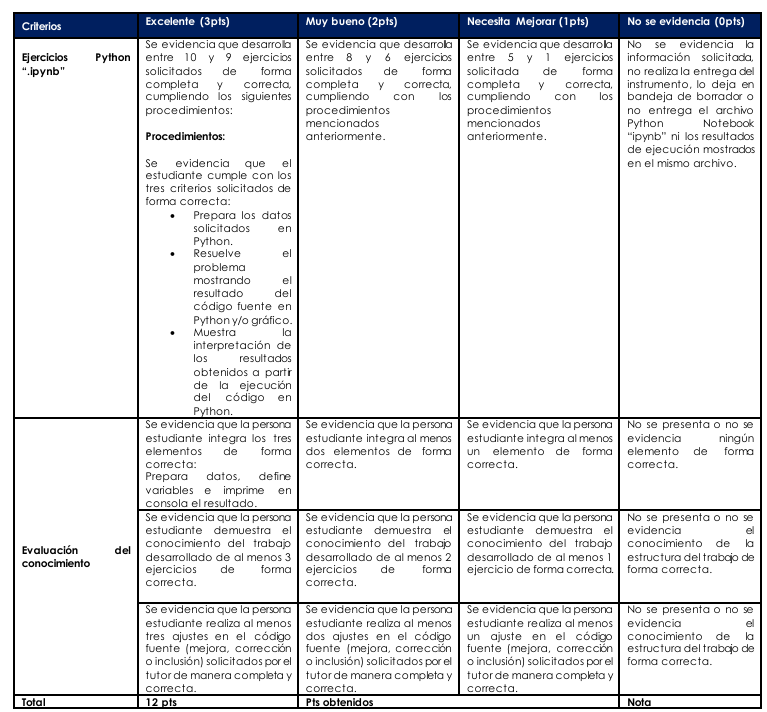